# A그룹 주 대상 공동집하거점 후보 위치 분석

이 노트북은 `population_adjusted_olist_usage_infrastructure.ipynb`에서 도출한 `A_infra_investment_candidate` 주를 대상으로 공동집하거점 후보 위치를 탐색한다.

공동집하거점은 판매자만을 위한 시설이 아니라, **소비자 배송 접근성과 지역 판매자 출고 접근성을 동시에 개선하는 양면 물류 인프라**로 정의한다. 따라서 후보 위치는 고객 수요 좌표만 보지 않고, 고객 배송 부담과 현재 판매자 공급 기반을 함께 반영한다.

분석 절차는 다음과 같다.

1. A그룹 주 필터링
2. 고객 수요 포인트와 판매자 공급 포인트 생성
3. 주문량, 배송 부담, 판매자 공급을 반영한 포인트 가중치 계산
4. 주별 무가중 K-Means로 1차 후보 중심 탐색
5. 중심점을 실제 도시/zip 포인트로 보정
6. 고객 수요, 배송 부담, 판매자 공급, 시장 격차를 종합한 후보 점수 산출

## 1. 라이브러리와 경로

In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 200)
pd.set_option("display.float_format", "{:,.4f}".format)

ROOT = Path.cwd()
while not (ROOT / "data" / "processed").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent

ORDER_DATA_PATH = ROOT / "data" / "processed" / "olist_delivered_item_level_cleaned_errors.csv"
CANDIDATE_PATH = ROOT / "notebooks" / "Distribution_hub" / "SG" / "Logistics_folder" / "outputs" / "infrastructure_investment_candidates.csv"
OUTPUT_DIR = ROOT / "notebooks" / "Distribution_hub" / "SG" / "Logistics_folder" / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

ORDER_DATA_PATH, CANDIDATE_PATH

(WindowsPath('c:/team-oldest-olist-analysis/data/processed/olist_delivered_item_level_cleaned_errors.csv'),
 WindowsPath('c:/team-oldest-olist-analysis/notebooks/Distribution_hub/SG/Logistics_folder/outputs/infrastructure_investment_candidates.csv'))

## 2. 데이터 로드와 A그룹 주 확정

`A_infra_investment_candidate`는 인구 대비 이용량이 낮고 배송 부담이 높은 주다. 이 그룹을 공동집하거점 우선 검토 대상으로 사용한다.

In [2]:
DATE_COLS = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
    "shipping_limit_date",
]

orders_raw = pd.read_csv(ORDER_DATA_PATH, parse_dates=DATE_COLS)
infra_candidates = pd.read_csv(CANDIDATE_PATH)

a_states = infra_candidates.loc[
    infra_candidates["candidate_group"].eq("A_infra_investment_candidate"), "uf"
].tolist()

print(f"A그룹 주 수: {len(a_states)}")
print(a_states)
display(infra_candidates[infra_candidates["uf"].isin(a_states)][[
    "uf", "region", "orders", "orders_per_100k", "avg_delivery_days", "late_rate", "infra_priority_score"
]])

A그룹 주 수: 9
['AL', 'MA', 'RR', 'SE', 'CE', 'PA', 'PI', 'PB', 'RN']


,uf,region,orders,orders_per_100k,avg_delivery_days,late_rate,infra_priority_score
0,AL,북동부,393,11.7225,23.8779,0.2366,0.8948
1,MA,북동부,704,10.0623,21.2188,0.2003,0.8626
2,RR,북부,40,7.4376,29.4500,0.1250,0.8292
3,SE,북동부,333,14.6219,21.0961,0.1532,0.8058
4,CE,북동부,1259,13.9580,20.9460,0.1557,0.8013
5,PA,북부,936,11.1637,23.3494,0.1229,0.7880
6,PI,북동부,469,14.5112,19.1215,0.1620,0.7783
8,PB,북동부,509,12.7023,20.0373,0.1100,0.7532
10,RN,북동부,467,13.3926,18.8587,0.1071,0.7330


## 3. 주문 단위 테이블과 배송 파생 변수

거점 위치 분석에서는 주문 중복을 피하기 위해 `order_id` 기준 주문 단위 테이블을 만든다. 판매자 공급 포인트 계산에는 item-level의 `seller_id`와 판매자 위치를 함께 사용한다.

In [3]:
orders_raw["handling_time_days"] = (
    orders_raw["order_delivered_carrier_date"] - orders_raw["order_approved_at"]
).dt.total_seconds() / 86_400
orders_raw["delivery_vs_estimated_days"] = (
    orders_raw["order_delivered_customer_date"] - orders_raw["order_estimated_delivery_date"]
).dt.total_seconds() / 86_400

first_cols = [
    "customer_unique_id",
    "customer_state",
    "customer_region",
    "customer_city",
    "customer_zip_code_prefix",
    "customer_geo_lat",
    "customer_geo_lng",
    "delivery_days_clean",
    "delivery_vs_estimated_days",
    "is_late",
    "review_score_mean",
]
order_df = orders_raw.groupby("order_id", as_index=False).agg({col: "first" for col in first_cols})

print(f"주문 단위 행 수: {len(order_df):,}")
display(order_df.head())

주문 단위 행 수: 95,082


,order_id,customer_unique_id,customer_state,customer_region,customer_city,customer_zip_code_prefix,customer_geo_lat,customer_geo_lng,delivery_days_clean,delivery_vs_estimated_days,is_late,review_score_mean
0,00010242fe8c5a6d1ba2dd792cb16214,871766c5855e863f6eccc05f988b23cb,RJ,남동부,campos dos goytacazes,28013,-21.7628,-41.3096,7,-8.0113,False,5.0000
1,00018f77f2f0320c557190d7a144bdd3,eb28e67c4c0b83846050ddfb8a35d051,SP,남동부,santa fe do sul,15775,-20.2205,-50.9034,16,-2.3303,False,4.0000
2,000229ec398224ef6ca0657da4fc703e,3818d81c6709e39d06b2738a8d3a2474,MG,남동부,para de minas,35661,-19.8703,-44.5933,7,-13.4450,False,5.0000
3,00024acbcdf0a6daa1e931b038114c75,af861d436cfc08b2c2ddefd0ba074622,SP,남동부,atibaia,12952,-23.0899,-46.6117,6,-5.4357,False,4.0000
4,00042b26cf59d7ce69dfabb4e55b4fd9,64b576fb70d441e8f1b2d7d446e483c5,SP,남동부,varzea paulista,13226,-23.2434,-46.8276,25,-15.3038,False,5.0000


## 4. 고객 수요 포인트 생성

고객 수요 포인트는 A그룹 주에 거주하는 고객 주문을 `customer_state + customer_zip_code_prefix + customer_city` 단위로 집계한다. 포인트별 주문 수와 배송 부담을 함께 계산한다.

In [4]:
customer_points = (
    order_df[order_df["customer_state"].isin(a_states)]
    .dropna(subset=["customer_geo_lat", "customer_geo_lng"])
    .groupby(["customer_state", "customer_region", "customer_zip_code_prefix", "customer_city"], as_index=False)
    .agg(
        lat=("customer_geo_lat", "mean"),
        lng=("customer_geo_lng", "mean"),
        customer_orders=("order_id", "nunique"),
        customers=("customer_unique_id", "nunique"),
        avg_delivery_days=("delivery_days_clean", "mean"),
        late_rate=("is_late", "mean"),
        avg_delivery_vs_estimated_days=("delivery_vs_estimated_days", "mean"),
        avg_review_score=("review_score_mean", "mean"),
    )
    .rename(columns={
        "customer_state": "state",
        "customer_region": "region",
        "customer_zip_code_prefix": "zip_code_prefix",
        "customer_city": "city",
    })
)
customer_points["point_role"] = "customer_demand"

display(customer_points.sort_values("customer_orders", ascending=False).head(20))

,state,region,zip_code_prefix,city,lat,lng,customer_orders,customers,avg_delivery_days,late_rate,avg_delivery_vs_estimated_days,avg_review_score,point_role
8,AL,북동부,57035,maceio,-9.6570,-35.7067,38,37,20.7105,0.1316,-10.6820,3.9211,customer_demand
544,MA,북동부,65075,sao luis,-2.5022,-44.2923,31,27,22.6452,0.2903,-5.0386,3.4500,customer_demand
827,PA,북부,68515,parauapebas,-6.0744,-49.9064,27,24,23.6667,0.1481,-12.3481,4.2308,customer_demand
910,PB,북동부,58038,joao pessoa,-7.1051,-34.8345,23,23,17.4348,0.1304,-14.0577,4.2609,customer_demand
718,PA,북부,66095,belem,-1.4368,-48.4554,21,21,19.5714,0.0952,-16.1445,4.3500,customer_demand
391,CE,북동부,62800,aracati,-4.5667,-37.7642,21,21,21.7143,0.0952,-12.2051,4.0000,customer_demand
540,MA,북동부,65071,sao luis,-2.4998,-44.2610,20,20,21.0500,0.2500,-12.3763,3.6842,customer_demand
1100,PI,북동부,64049,teresina,-5.0681,-42.7887,20,18,15.9500,0.1500,-12.1601,4.2105,customer_demand
704,PA,북부,66055,belem,-1.4445,-48.4845,20,20,19.9500,0.1000,-15.2098,3.7000,customer_demand
536,MA,북동부,65066,sao luis,-2.5163,-44.2282,19,19,16.1579,0.2105,-9.8925,4.4211,customer_demand


## 5. 판매자 공급 포인트 생성

판매자 공급 포인트는 A그룹 주에 위치한 판매자를 `seller_state + seller_zip_code_prefix + seller_city` 단위로 집계한다. 현재 판매자 기반은 초기 집하 물량과 신규 판매자 유입 가능성을 판단하는 대리 지표로 사용한다.

In [5]:
seller_filter = orders_raw["seller_state"].isin(a_states)
if "is_seller_geo_unreliable" in orders_raw.columns:
    seller_filter &= ~orders_raw["is_seller_geo_unreliable"].fillna(False)
if "seller_state_geo_mismatch" in orders_raw.columns:
    seller_filter &= ~orders_raw["seller_state_geo_mismatch"].fillna(False)
if "seller_geo_state" in orders_raw.columns:
    seller_filter &= orders_raw["seller_geo_state"].eq(orders_raw["seller_state"])

seller_points = (
    orders_raw[seller_filter]
    .dropna(subset=["seller_geo_lat", "seller_geo_lng"])
    .groupby(["seller_state", "seller_region", "seller_zip_code_prefix", "seller_city"], as_index=False)
    .agg(
        lat=("seller_geo_lat", "mean"),
        lng=("seller_geo_lng", "mean"),
        seller_orders=("order_id", "nunique"),
        sellers=("seller_id", "nunique"),
        avg_handling_days=("handling_time_days", "mean"),
    )
    .rename(columns={
        "seller_state": "state",
        "seller_region": "region",
        "seller_zip_code_prefix": "zip_code_prefix",
        "seller_city": "city",
    })
)
seller_points["point_role"] = "seller_supply"

display(seller_points.sort_values("seller_orders", ascending=False).head(20))

,state,region,zip_code_prefix,city,lat,lng,seller_orders,sellers,avg_handling_days,point_role
12,MA,북동부,65072,sao luis,-2.5012,-44.2482,370,1,4.7635,seller_supply
7,CE,북동부,61658,caucaia,-3.7668,-38.6554,26,1,2.3196,seller_supply
20,RN,북동부,59020,natal,-5.7922,-35.2015,20,1,1.1613,seller_supply
5,CE,북동부,60710,fortaleza,-3.7866,-38.5679,15,1,0.8741,seller_supply
3,CE,북동부,60348,fortaleza,-3.7175,-38.5993,14,1,0.8574,seller_supply
21,RN,북동부,59077,natal,-5.8402,-35.2079,14,1,9.7825,seller_supply
15,PB,북동부,58280,mamanguape,-6.8372,-35.1269,14,1,4.0341,seller_supply
22,RN,북동부,59152,parnamirim,-5.8866,-35.2082,14,1,2.3688,seller_supply
19,PI,북동부,64033,teresina,-5.1236,-42.7683,11,1,1.5209,seller_supply
6,CE,북동부,60741,fortaleza,-3.7899,-38.5506,11,1,4.8849,seller_supply


## 6. 클러스터링 입력 포인트 통합

기존 방식에서는 고객 수요 포인트와 판매자 공급 포인트에 각각 65%, 35%의 총량 가중치를 부여하였다.

그러나 후보 거점 점수화 단계에서 이미 고객 수요, 시장 격차, 배송 부담, 판매자 공급을 종합적으로 평가하고 있으므로, 후보 생성 단계에서 동일한 요소를 다시 가중하면 특정 요인이 중복 반영될 수 있다.

따라서 본 분석에서는 후보 생성 단계와 후보 평가 단계를 분리한다.

- 후보 생성 단계: 무가중 K-Means로 지리적 후보 중심 탐색
- 후보 평가 단계: `hub_score`로 고객 수요, 시장 격차, 배송 부담, 판매자 공급을 종합 평가

이 방식은 65:35와 같은 임의 가중치 설정을 제거하고, 후보 위치 탐색과 후보 평가의 역할을 명확히 분리한다.

In [6]:
def minmax(s):
    s = s.astype(float)
    if len(s) == 0 or s.max() == s.min():
        return pd.Series(0.5, index=s.index)
    return (s - s.min()) / (s.max() - s.min())

common_cols = [
    "state", "region", "zip_code_prefix", "city",
    "lat", "lng", "point_role"
]

customer_common = customer_points.assign(
    seller_orders=0,
    sellers=0,
)[
    common_cols + [
        "customer_orders",
        "customers",
        "avg_delivery_days",
        "late_rate",
        "avg_delivery_vs_estimated_days",
        "avg_review_score",
        "seller_orders",
        "sellers"
    ]
]

if len(seller_points) > 0:
    seller_common = seller_points.assign(
        customer_orders=0,
        customers=0,
        avg_delivery_days=np.nan,
        late_rate=np.nan,
        avg_delivery_vs_estimated_days=np.nan,
        avg_review_score=np.nan,
    )[
        common_cols + [
            "customer_orders",
            "customers",
            "avg_delivery_days",
            "late_rate",
            "avg_delivery_vs_estimated_days",
            "avg_review_score",
            "seller_orders",
            "sellers"
        ]
    ]
else:
    seller_common = pd.DataFrame(columns=customer_common.columns)

hub_points = pd.concat(
    [customer_common, seller_common],
    ignore_index=True
)

display(hub_points.head())
print("hub_points shape:", hub_points.shape)

,state,region,zip_code_prefix,city,lat,lng,point_role,customer_orders,customers,avg_delivery_days,late_rate,avg_delivery_vs_estimated_days,avg_review_score,seller_orders,sellers
0,AL,북동부,57010,maceio,-9.6687,-35.7557,customer_demand,9,9,20.7778,0.3333,-4.4854,3.6667,0,0
1,AL,북동부,57014,maceio,-9.6584,-35.7567,customer_demand,6,6,32.1667,0.3333,3.2982,4.0000,0,0
2,AL,북동부,57015,maceio,-9.6539,-35.7577,customer_demand,3,3,25.0000,0.0000,-10.6164,4.6667,0,0
3,AL,북동부,57017,maceio,-9.6370,-35.7474,customer_demand,8,8,26.1250,0.3750,-8.3878,3.7143,0,0
4,AL,북동부,57020,maceio,-9.6378,-35.7409,customer_demand,1,1,21.0000,0.0000,-9.2176,4.0000,0,0


hub_points shape: (1513, 15)


## 7. 주별 무가중 K-Means 후보 탐색

주별 후보 거점 위치는 무가중 K-Means로 탐색한다.

무가중 K-Means를 사용하는 이유는 후보 생성 단계에서는 지리적으로 가능한 중심 위치를 먼저 찾고, 후보의 실제 타당성은 이후 `hub_score`에서 평가하기 위함이다.

즉, 이 단계에서는 고객 수요나 판매자 공급을 직접 가중하지 않고, 고객/판매자 포인트의 지리적 분포를 기반으로 후보 중심을 생성한다.

후보 거점 수 `k`는 기존 방식과 동일하게 주별 주문 수에 따라 다르게 설정한다.

| 주별 주문 수 | 후보 거점 수 |
|---:|---:|
| 500건 이하 | 1 |
| 501~1,500건 | 2 |
| 1,500건 초과 | 3 |

In [7]:
def haversine_km(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(
        np.radians,
        [lat1, lon1, lat2, lon2]
    )
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = (
        np.sin(dlat / 2) ** 2
        + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    )
    return 6_371 * 2 * np.arcsin(np.sqrt(a))

def choose_k(order_count):
    if order_count <= 500:
        return 1
    if order_count <= 1500:
        return 2
    return 3

state_order_map = infra_candidates.set_index("uf")["orders"].to_dict()
state_gap_map = infra_candidates.set_index("uf")["under_usage_score"].to_dict()
state_priority_map = infra_candidates.set_index("uf")["infra_priority_score"].to_dict()

clustered_frames = []
hub_rows = []

for state in a_states:
    points = hub_points[hub_points["state"].eq(state)].copy().reset_index(drop=True)
    
    if points.empty:
        continue
    
    k = min(
        choose_k(state_order_map.get(state, 0)),
        len(points)
    )
    
    coords = points[["lat", "lng"]].to_numpy()
    
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )
    
    labels = model.fit_predict(coords)
    points["hub_cluster"] = labels
    points["distance_to_hub_km"] = np.nan
    
    for cluster_id in range(k):
        cluster_points = points[points["hub_cluster"].eq(cluster_id)].copy()
        
        center_lat, center_lng = model.cluster_centers_[cluster_id]
        
        cluster_points["distance_to_center_km"] = haversine_km(
            cluster_points["lat"],
            cluster_points["lng"],
            center_lat,
            center_lng
        )
        
        # 중심점은 실제 도시/zip이 아닐 수 있으므로 가장 가까운 실제 고객 수요 포인트로 보정
        snap_candidates = cluster_points[
            cluster_points["point_role"].eq("customer_demand")
        ]
        
        if snap_candidates.empty:
            snap_candidates = cluster_points
        
        snap = snap_candidates.sort_values("distance_to_center_km").iloc[0]
        
        cluster_points["distance_to_hub_km"] = haversine_km(
            cluster_points["lat"],
            cluster_points["lng"],
            snap["lat"],
            snap["lng"]
        )
        
        points.loc[
            points["hub_cluster"].eq(cluster_id),
            "distance_to_hub_km"
        ] = cluster_points["distance_to_hub_km"].to_numpy()
        
        customer_part = cluster_points[
            cluster_points["point_role"].eq("customer_demand")
        ]
        
        seller_part = cluster_points[
            cluster_points["point_role"].eq("seller_supply")
        ]
        
        if (
            customer_part["customer_orders"].sum() > 0
            and customer_part["avg_delivery_days"].notna().any()
        ):
            avg_delivery_days = np.average(
                customer_part.loc[
                    customer_part["avg_delivery_days"].notna(),
                    "avg_delivery_days"
                ],
                weights=customer_part.loc[
                    customer_part["avg_delivery_days"].notna(),
                    "customer_orders"
                ]
            )
        else:
            avg_delivery_days = np.nan
        
        if (
            customer_part["customer_orders"].sum() > 0
            and customer_part["late_rate"].notna().any()
        ):
            late_rate = np.average(
                customer_part.loc[
                    customer_part["late_rate"].notna(),
                    "late_rate"
                ],
                weights=customer_part.loc[
                    customer_part["late_rate"].notna(),
                    "customer_orders"
                ]
            )
        else:
            late_rate = np.nan
        
        hub_rows.append({
            "state": state,
            "region": snap["region"],
            "hub_cluster": cluster_id,
            "suggested_city": snap["city"],
            "suggested_zip_code_prefix": snap["zip_code_prefix"],
            "hub_lat": snap["lat"],
            "hub_lng": snap["lng"],
            "snap_point_role": snap["point_role"],
            "cluster_points": len(cluster_points),
            "covered_customer_orders": customer_part["customer_orders"].sum(),
            "covered_customers": customer_part["customers"].sum(),
            "covered_seller_orders": seller_part["seller_orders"].sum(),
            "covered_sellers": seller_part["sellers"].sum(),
            "avg_delivery_days": avg_delivery_days,
            "late_rate": late_rate,
            "avg_distance_to_hub_km": cluster_points["distance_to_hub_km"].mean(),
            "p75_distance_to_hub_km": cluster_points["distance_to_hub_km"].quantile(0.75),
            "state_under_usage_score": state_gap_map.get(state, np.nan),
            "state_infra_priority_score": state_priority_map.get(state, np.nan),
        })
    
    clustered_frames.append(points)

hub_candidate_points = pd.concat(clustered_frames, ignore_index=True)
hub_candidates = pd.DataFrame(hub_rows)

display(hub_candidates)

,state,region,hub_cluster,suggested_city,suggested_zip_code_prefix,hub_lat,hub_lng,snap_point_role,cluster_points,covered_customer_orders,covered_customers,covered_seller_orders,covered_sellers,avg_delivery_days,late_rate,avg_distance_to_hub_km,p75_distance_to_hub_km,state_under_usage_score,state_infra_priority_score
0,AL,북동부,0,anadia,57660,-9.6840,-36.3033,customer_demand,123,392,383,0,0,23.9031,0.2372,75.1028,67.1964,0.9038,0.8948
1,MA,북동부,0,santa rita,65145,-3.1354,-44.3209,customer_demand,143,542,530,370,1,20.8081,0.2011,117.9973,160.3470,0.9233,0.8626
2,MA,북동부,1,grajau,65940,-5.8173,-46.1456,customer_demand,48,159,155,0,0,22.2830,0.1887,177.7360,213.6199,0.9233,0.8626
3,RR,북부,0,boa vista,69307,2.8556,-60.6607,customer_demand,15,40,39,0,0,29.4500,0.1250,12.8633,8.2916,0.9543,0.8292
4,SE,북동부,0,riachuelo,49130,-10.7314,-37.1869,customer_demand,88,332,327,9,2,21.0873,0.1536,42.4721,57.4964,0.8696,0.8058
5,CE,북동부,0,caucaia,61637,-3.6626,-38.7981,customer_demand,308,1048,1030,84,10,21.0725,0.1670,74.5773,121.1434,0.8774,0.8013
6,CE,북동부,1,varzea alegre,63540,-6.7926,-39.2986,customer_demand,82,207,206,2,2,20.4300,0.1014,79.5278,102.9115,0.8774,0.8013
7,PA,북부,0,quatro bocas,68682,-2.5850,-49.1252,customer_demand,201,932,909,0,0,23.3573,0.1234,269.9434,310.6866,0.9104,0.7880
8,PA,북부,1,porto trombetas,68275,22.5680,-27.6981,customer_demand,1,2,2,0,0,27.0000,0.0000,0.0000,0.0000,0.9104,0.7880
9,PI,북동부,0,lagoinha do piaui,64465,-5.8374,-42.6280,customer_demand,152,466,455,11,1,19.1266,0.1609,169.3592,248.9222,0.8709,0.7783


## 8. 후보 거점 점수화

무가중 K-Means로 도출된 후보 거점은 다음 네 가지 기준으로 평가한다.

1. 고객 수요
2. 시장 격차
3. 배송 부담
4. 판매자 공급 기반

후보 생성 단계에서는 가중치를 제거했으므로, 실제 후보의 우선순위는 이 점수화 단계에서 결정된다.

기본 점수식은 다음과 같다.

```text
hub_score =
0.35 * customer_demand_score
+ 0.30 * market_gap_score
+ 0.20 * delivery_burden_score
+ 0.15 * seller_supply_score

In [8]:
hub_candidates["customer_demand_score"] = minmax(
    hub_candidates["covered_customer_orders"]
)

hub_candidates["seller_supply_raw"] = (
    hub_candidates["covered_seller_orders"]
    + 10 * hub_candidates["covered_sellers"]
)

hub_candidates["seller_supply_score"] = minmax(
    hub_candidates["seller_supply_raw"]
)

hub_candidates["delivery_burden_score"] = (
    0.65 * minmax(
        hub_candidates["avg_delivery_days"].fillna(
            hub_candidates["avg_delivery_days"].median()
        )
    )
    + 0.35 * minmax(
        hub_candidates["late_rate"].fillna(0)
    )
)

hub_candidates["market_gap_score"] = hub_candidates[
    "state_under_usage_score"
]

base_weights = {
    "customer_demand_score": 0.35,
    "market_gap_score": 0.30,
    "delivery_burden_score": 0.20,
    "seller_supply_score": 0.15,
}

hub_candidates["hub_score"] = sum(
    w * hub_candidates[col]
    for col, w in base_weights.items()
)

hub_candidates = hub_candidates.sort_values(
    "hub_score",
    ascending=False
)

display(hub_candidates[
    [
        "state",
        "region",
        "suggested_city",
        "suggested_zip_code_prefix",
        "hub_score",
        "covered_customer_orders",
        "covered_customers",
        "covered_seller_orders",
        "covered_sellers",
        "avg_delivery_days",
        "late_rate",
        "avg_distance_to_hub_km",
        "state_under_usage_score",
    ]
])

,state,region,suggested_city,suggested_zip_code_prefix,hub_score,covered_customer_orders,covered_customers,covered_seller_orders,covered_sellers,avg_delivery_days,late_rate,avg_distance_to_hub_km,state_under_usage_score
5,CE,북동부,caucaia,61637,0.7626,1048,1030,84,10,21.0725,0.1670,74.5773,0.8774
1,MA,북동부,santa rita,65145,0.6912,542,530,370,1,20.8081,0.2011,117.9973,0.9233
7,PA,북부,quatro bocas,68682,0.6761,932,909,0,0,23.3573,0.1234,269.9434,0.9104
0,AL,북동부,anadia,57660,0.5337,392,383,0,0,23.9031,0.2372,75.1028,0.9038
12,RN,북동부,sao tome,59400,0.4864,465,455,49,4,18.8301,0.1054,116.2621,0.8841
10,PB,북동부,mari,58345,0.4807,409,397,26,5,19.8875,0.1149,56.2463,0.8922
9,PI,북동부,lagoinha do piaui,64465,0.4759,466,455,11,1,19.1266,0.1609,169.3592,0.8709
3,RR,북부,boa vista,69307,0.4659,40,39,0,0,29.4500,0.1250,12.8633,0.9543
4,SE,북동부,riachuelo,49130,0.4557,332,327,9,2,21.0873,0.1536,42.4721,0.8696
2,MA,북동부,grajau,65940,0.4275,159,155,0,0,22.2830,0.1887,177.7360,0.9233


# 8-1. Hub Score 가중치 근거 보완

## 분석 목적

기본 `hub_score`는 고객 수요, 시장 격차, 배송 부담, 판매자 공급 기반을 반영한다.

다만 각 기준의 가중치가 주관적으로 설정되었다는 한계가 있으므로, 다음 네 가지 방법을 사용해 가중치 근거를 보완한다.

| 방법 | 성격 | 의미 |
|---|---|---|
| AHP | 주관/전략 기반 | 분석 목적에 따른 기준 간 중요도 반영 |
| Entropy | 객관/분산 기반 | 후보 간 차이를 많이 만드는 지표에 높은 가중치 |
| CRITIC | 객관/대비·상관 기반 | 변동성이 크고 다른 지표와 중복이 적은 지표에 높은 가중치 |
| PCA | 객관/차원축소 기반 | 전체 분산을 설명하는 주성분 기여도 기반 가중치 |

최종적으로 각 방법의 가중치를 비교하고, 기본 가중치가 과도하게 임의적인지 점검한다.

In [9]:
from sklearn.decomposition import PCA

score_cols = [
    "customer_demand_score",
    "market_gap_score",
    "delivery_burden_score",
    "seller_supply_score"
]

score_name_map = {
    "customer_demand_score": "고객 수요",
    "market_gap_score": "시장 격차",
    "delivery_burden_score": "배송 부담",
    "seller_supply_score": "판매자 공급",
}

score_matrix = hub_candidates[score_cols].copy()

for col in score_cols:
    score_matrix[col] = pd.to_numeric(score_matrix[col], errors="coerce")

score_matrix = score_matrix.fillna(score_matrix.median())

# 0~1 정규화
X_score = score_matrix.apply(minmax)

## AHP 가중치

AHP는 분석자가 생각하는 전략적 중요도를 쌍대비교 행렬로 표현하는 방식이다.

여기서는 공동집하거점의 목적을 다음 순서로 둔다.

1. 고객 수요
2. 시장 격차
3. 배송 부담
4. 판매자 공급

이는 공동집하거점이 현재 이용량이 낮고 배송 부담이 큰 지역에서 소비자 배송 접근성과 시장 침투율을 개선하는 목적을 갖기 때문이다.

In [10]:
def ahp_weights(pairwise_matrix):
    eigvals, eigvecs = np.linalg.eig(pairwise_matrix)
    max_idx = np.argmax(eigvals.real)
    max_eigval = eigvals.real[max_idx]
    weights = eigvecs[:, max_idx].real
    weights = weights / weights.sum()
    
    n = pairwise_matrix.shape[0]
    ci = (max_eigval - n) / (n - 1)
    ri_dict = {
        1: 0.00,
        2: 0.00,
        3: 0.58,
        4: 0.90,
        5: 1.12,
        6: 1.24,
        7: 1.32,
        8: 1.41,
        9: 1.45,
        10: 1.49
    }
    ri = ri_dict.get(n, 1.49)
    cr = ci / ri if ri != 0 else 0
    
    return weights, max_eigval, ci, cr

# 기준 순서:
# customer_demand_score, market_gap_score, delivery_burden_score, seller_supply_score
ahp_matrix = np.array([
    [1,   2,   2,   3],
    [1/2, 1,   2,   2],
    [1/2, 1/2, 1,   2],
    [1/3, 1/2, 1/2, 1],
], dtype=float)

ahp_w, ahp_lambda, ahp_ci, ahp_cr = ahp_weights(ahp_matrix)

ahp_weight_series = pd.Series(
    ahp_w,
    index=score_cols,
    name="AHP"
)

print("AHP weights")
display(ahp_weight_series)
print("Consistency Ratio:", ahp_cr)

AHP weights


customer_demand_score   0.4182
market_gap_score        0.2707
delivery_burden_score   0.1906
seller_supply_score     0.1205
Name: AHP, dtype: float64

Consistency Ratio: 0.026300954629484025


AHP의 일관성 비율인 CR이 일반적으로 0.1 이하이면 쌍대비교가 비교적 일관적이라고 해석한다.

CR이 너무 높다면 쌍대비교 행렬을 다시 조정해야 한다.

## Entropy 가중치

Entropy 가중치는 지표의 정보량을 기반으로 한다.

후보 간 값의 차이가 큰 지표는 더 많은 정보를 제공하므로 높은 가중치를 받는다.  
반대로 모든 후보가 비슷한 값을 갖는 지표는 구분력이 낮아 낮은 가중치를 받는다.

In [11]:
def entropy_weights(X):
    X = X.copy().astype(float)
    eps = 1e-12
    
    # 0 값을 피하기 위해 작은 값 추가
    P = X + eps
    P = P / P.sum(axis=0)
    
    n = len(P)
    entropy = -(P * np.log(P)).sum(axis=0) / np.log(n)
    diversity = 1 - entropy
    weights = diversity / diversity.sum()
    
    return pd.Series(weights, index=X.columns, name="Entropy")

entropy_weight_series = entropy_weights(X_score)

display(entropy_weight_series)

customer_demand_score   0.1638
market_gap_score        0.1797
delivery_burden_score   0.1425
seller_supply_score     0.5139
Name: Entropy, dtype: float64

## CRITIC 가중치

CRITIC은 지표의 표준편차와 지표 간 상관관계를 함께 고려한다.

변동성이 크고 다른 지표와 중복되지 않는 지표는 더 높은 가중치를 받는다.

즉, 후보들을 잘 구분하면서도 다른 지표와 비슷한 정보를 반복하지 않는 지표를 중요하게 평가한다.

In [12]:
def critic_weights(X):
    X = X.copy().astype(float)
    
    std = X.std(axis=0)
    corr = X.corr().fillna(0)
    
    conflict = (1 - corr).sum(axis=0)
    information = std * conflict
    
    weights = information / information.sum()
    
    return pd.Series(weights, index=X.columns, name="CRITIC")

critic_weight_series = critic_weights(X_score)

display(critic_weight_series)

customer_demand_score   0.2950
market_gap_score        0.2306
delivery_burden_score   0.2294
seller_supply_score     0.2450
Name: CRITIC, dtype: float64

## PCA 기반 가중치

PCA는 여러 지표가 가진 전체 분산 구조를 요약한다.

여기서는 각 주성분의 설명분산비율과 변수 loading의 절댓값을 이용해 지표별 기여도를 계산한다.

PCA 가중치는 여러 지표가 함께 만드는 변동 구조에서 어떤 지표가 더 큰 역할을 하는지 확인하는 참고 지표로 사용한다.

In [13]:
def pca_weights(X):
    X = X.copy().astype(float)
    
    # PCA는 평균 0, 표준편차 1 스케일에서 수행
    X_std = (X - X.mean()) / X.std(ddof=0)
    X_std = X_std.fillna(0)
    
    pca = PCA()
    pca.fit(X_std)
    
    loadings = np.abs(pca.components_.T)
    explained = pca.explained_variance_ratio_
    
    contribution = loadings @ explained
    weights = contribution / contribution.sum()
    
    return pd.Series(weights, index=X.columns, name="PCA"), pca

pca_weight_series, pca_model = pca_weights(X_score)

display(pca_weight_series)
print("Explained variance ratio:", pca_model.explained_variance_ratio_)

customer_demand_score   0.2582
market_gap_score        0.2482
delivery_burden_score   0.2523
seller_supply_score     0.2413
Name: PCA, dtype: float64

Explained variance ratio: [0.49719427 0.31238454 0.15191601 0.03850518]


## 가중치 비교 및 대안 Hub Score 계산

기본 가중치와 AHP, Entropy, CRITIC, PCA 가중치를 비교한다.

가중치 방법별로 후보 순위가 얼마나 달라지는지도 확인한다.

In [14]:
base_weight_series = pd.Series(
    base_weights,
    name="Base"
)[score_cols]

weight_compare = pd.concat(
    [
        base_weight_series,
        ahp_weight_series,
        entropy_weight_series,
        critic_weight_series,
        pca_weight_series
    ],
    axis=1
)

weight_compare.index = [
    score_name_map[col]
    for col in weight_compare.index
]

display(weight_compare.round(4))

,Base,AHP,Entropy,CRITIC,PCA
고객 수요,0.3500,0.4182,0.1638,0.2950,0.2582
시장 격차,0.3000,0.2707,0.1797,0.2306,0.2482
배송 부담,0.2000,0.1906,0.1425,0.2294,0.2523
판매자 공급,0.1500,0.1205,0.5139,0.2450,0.2413


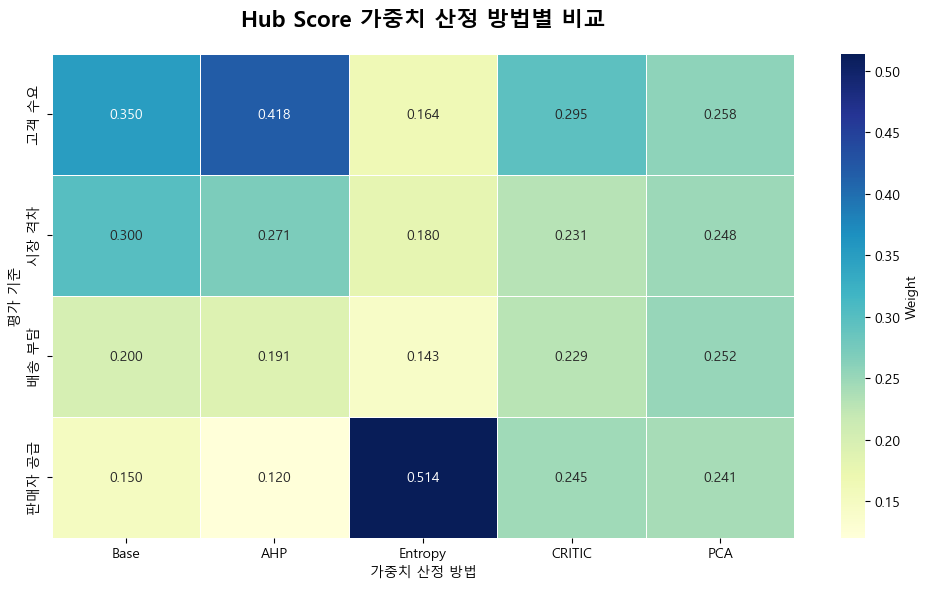

In [15]:
plt.figure(figsize=(10, 6))

sns.heatmap(
    weight_compare,
    cmap="YlGnBu",
    annot=True,
    fmt=".3f",
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Weight"}
)

plt.title("Hub Score 가중치 산정 방법별 비교", fontsize=16, weight="bold", pad=20)
plt.xlabel("가중치 산정 방법")
plt.ylabel("평가 기준")

plt.tight_layout()
plt.show()

In [16]:
# 방법별 hub score 계산
weight_method_map = {
    "base": base_weight_series,
    "ahp": ahp_weight_series,
    "entropy": entropy_weight_series,
    "critic": critic_weight_series,
    "pca": pca_weight_series,
}

for method_name, weights in weight_method_map.items():
    hub_candidates[f"hub_score_{method_name}"] = sum(
        weights[col] * hub_candidates[col]
        for col in score_cols
    )

rank_cols = []
for method_name in weight_method_map.keys():
    score_col = f"hub_score_{method_name}"
    rank_col = f"rank_{method_name}"
    hub_candidates[rank_col] = hub_candidates[score_col].rank(
        ascending=False,
        method="min"
    )
    rank_cols.append(rank_col)

hub_candidates["rank_mean"] = hub_candidates[rank_cols].mean(axis=1)
hub_candidates["rank_std"] = hub_candidates[rank_cols].std(axis=1)
hub_candidates["top5_count"] = (
    hub_candidates[rank_cols] <= 5
).sum(axis=1)

stable_hub_candidates = hub_candidates.sort_values(
    ["top5_count", "rank_mean", "rank_std"],
    ascending=[False, True, True]
)

display(stable_hub_candidates[
    [
        "state",
        "region",
        "suggested_city",
        "suggested_zip_code_prefix",
        "hub_score_base",
        "hub_score_ahp",
        "hub_score_entropy",
        "hub_score_critic",
        "hub_score_pca",
        "rank_mean",
        "rank_std",
        "top5_count",
        "covered_customer_orders",
        "avg_delivery_days",
        "late_rate",
        "covered_sellers"
    ]
].head(15))

,state,region,suggested_city,suggested_zip_code_prefix,hub_score_base,hub_score_ahp,hub_score_entropy,hub_score_critic,hub_score_pca,rank_mean,rank_std,top5_count,covered_customer_orders,avg_delivery_days,late_rate,covered_sellers
5,CE,북동부,caucaia,61637,0.7626,0.7872,0.6251,0.7040,0.6896,1.6000,0.5477,5,1048,21.0725,0.1670,10
1,MA,북동부,santa rita,65145,0.6912,0.6660,0.8240,0.7061,0.7092,1.6000,0.8944,5,542,20.8081,0.2011,1
7,PA,북부,quatro bocas,68682,0.6761,0.7058,0.3747,0.5776,0.5714,2.8000,0.4472,5,932,23.3573,0.1234,0
0,AL,북동부,anadia,57660,0.5337,0.5265,0.3177,0.4699,0.4872,4.4000,0.8944,4,392,23.9031,0.2372,0
12,RN,북동부,sao tome,59400,0.4864,0.4823,0.3740,0.4275,0.4295,5.0000,0.7071,4,465,18.8301,0.1054,4
10,PB,북동부,mari,58345,0.4807,0.4730,0.3603,0.4233,0.4293,6.2000,0.8367,1,409,19.8875,0.1149,5
3,RR,북부,boa vista,69307,0.4659,0.4326,0.2964,0.4222,0.4567,7.4000,1.5166,1,40,29.4500,0.1250,0
9,PI,북동부,lagoinha do piaui,64465,0.4759,0.4766,0.2940,0.4039,0.4085,7.6000,1.1402,0,466,19.1266,0.1609,1
4,SE,북동부,riachuelo,49130,0.4557,0.4461,0.2992,0.3960,0.4078,8.4000,0.8944,0,332,21.0873,0.1536,2
2,MA,북동부,grajau,65940,0.4275,0.4061,0.2603,0.3696,0.3915,10.0000,0.0000,0,159,22.2830,0.1887,0


## 가중치 근거 해석

본 분석에서는 후보 생성 단계에서 고객/판매자 포인트 가중치를 제거하고, 후보 평가 단계에서 `hub_score`를 통해 평가 기준을 반영하였다.

기본 가중치는 분석 목적에 따라 고객 수요와 시장 격차를 상대적으로 중요하게 설정한 값이다.

다만 가중치 설정의 임의성을 줄이기 위해 AHP, Entropy, CRITIC, PCA 기반 가중치를 함께 계산하였다.

- AHP는 분석 목적에 따른 전략적 중요도를 반영한다.
- Entropy는 후보 간 차이를 많이 만드는 지표에 높은 가중치를 준다.
- CRITIC은 변동성이 크고 다른 지표와 중복이 적은 지표를 중요하게 본다.
- PCA는 전체 분산 구조에서 각 지표의 기여도를 확인한다.

최종 후보는 특정 가중치 하나에서만 상위권인 후보보다, 여러 가중치 방식에서 반복적으로 상위권에 등장하는 후보를 안정 후보로 해석한다.

따라서 `top5_count`가 높고 `rank_mean`이 낮으며 `rank_std`가 작은 후보는 가중치 방식이 달라져도 일관되게 우수한 후보로 볼 수 있다.

기존:
무가중 K-Means로 지리적 후보 중심 탐색
→ hub_score에서 또 고객/배송/판매자 반영
→ 중복 반영 가능

수정:
무가중 K-Means로 후보 위치 생성
→ hub_score로 후보 평가
→ AHP/Entropy/CRITIC/PCA로 hub_score 가중치 근거 보완

## 9. 벤치마크 시나리오 기대상승 주문량 결합

`population_adjusted_olist_usage_infrastructure.ipynb`에서 만든 보수적/중립적/공격적 벤치마크 시나리오를 A그룹 주 단위로 다시 적용한다. 여기서 기대상승 주문량은 인프라 투자 효과를 직접 관측한 값이 아니라, 성숙 권역 이용률과 현재 이용률의 격차를 인구 규모로 환산한 시장 기회 규모다.

해석 기준은 다음과 같다.

- `orders_per_100k`: 현재 인구 10만 명당 주문 수다. 낮을수록 아직 Olist 이용이 덜 확산된 주로 본다.
- `benchmark_orders_per_100k`: 성숙 권역을 기준으로 잡은 목표 이용률이다. 보수적은 낮은 목표, 중립적은 평균적 목표, 공격적은 높은 목표다.
- `gap_orders_per_100k`: 벤치마크 이용률과 현재 이용률의 차이다. 이 값이 클수록 현재 이용률과 목표 이용률 사이의 여지가 크다.
- `expected_additional_orders`: 위 격차를 해당 주의 인구 규모에 곱해 환산한 기대상승 주문량이다. 값이 클수록 인프라 개선으로 열릴 수 있는 시장 기회가 크다고 해석한다.
- `expected_additional_orders_lower`, `expected_additional_orders_upper`: 관측 주문 수의 불확실성을 반영한 하한과 상한이다. 투자 효과의 인과적 신뢰구간이 아니라, 현재 이용률 격차를 주문 수로 바꿀 때 생기는 범위로 이해한다.
- `infra_priority_score`: 저이용 정도와 배송 부담을 합쳐 만든 인프라 우선순위 점수다. 기대상승 주문량이 크고 이 점수도 높으면, 수요 기회와 물류 개선 필요성이 동시에 큰 후보로 볼 수 있다.

그 다음 이 값을 무가중 공동집하거점 후보 결과와 결합한다. 이때는 단순히 기대상승 주문량만 보지 않고, `hub_candidates_count`, `top_hub_score`, `total_covered_customer_orders`, `total_covered_seller_orders`, `mean_distance_to_hub_km`를 함께 본다. 즉, "주문이 늘어날 여지"와 "그 여지를 받아낼 거점 후보의 품질"을 같이 해석한다.

예를 들어 기대상승 주문량은 큰데 후보 거점의 `hub_score`가 낮거나 평균 커버 거리가 길다면, 시장 기회는 크지만 실제 운영 설계가 더 어려운 지역일 수 있다. 반대로 기대상승 주문량이 크고 상위 거점의 `hub_score`도 높다면, 공동집하거점 우선 검토 대상으로 더 설득력이 있다.

In [17]:
BENCHMARK_SCENARIO_PATH = OUTPUT_DIR / "infrastructure_benchmark_scenarios.csv"
REGION_EXPECTED_EFFECT_PATH = OUTPUT_DIR / "infrastructure_expected_effect_by_region.csv"

benchmark_scenarios = pd.read_csv(BENCHMARK_SCENARIO_PATH)
region_expected_effect = pd.read_csv(REGION_EXPECTED_EFFECT_PATH)

a_state_base = infra_candidates[
    infra_candidates["candidate_group"].eq("A_infra_investment_candidate")
].copy()

state_expected_rows = []
for _, scenario in benchmark_scenarios.iterrows():
    tmp = a_state_base.copy()
    for col in benchmark_scenarios.columns:
        tmp[col] = scenario[col]
    tmp["gap_orders_per_100k"] = (
        tmp["benchmark_orders_per_100k"] - tmp["orders_per_100k"]
    ).clip(lower=0)
    tmp["gap_orders_per_100k_lower"] = (
        tmp["benchmark_ci_lower"] - tmp["orders_per_100k"]
    ).clip(lower=0)
    tmp["gap_orders_per_100k_upper"] = (
        tmp["benchmark_ci_upper"] - tmp["orders_per_100k"]
    ).clip(lower=0)
    tmp["expected_additional_orders"] = (
        tmp["gap_orders_per_100k"] * tmp["avg_population"] / 100_000
    )
    tmp["expected_additional_orders_lower"] = (
        tmp["gap_orders_per_100k_lower"] * tmp["avg_population"] / 100_000
    )
    tmp["expected_additional_orders_upper"] = (
        tmp["gap_orders_per_100k_upper"] * tmp["avg_population"] / 100_000
    )
    state_expected_rows.append(tmp)

state_expected_effect = pd.concat(state_expected_rows, ignore_index=True)
state_expected_effect = state_expected_effect.sort_values(
    ["scenario", "expected_additional_orders"], ascending=[True, False]
)

region_expected_from_states = (
    state_expected_effect
    .groupby(["scenario", "region"], as_index=False)
    .agg(
        target_states=("uf", "nunique"),
        current_orders=("orders", "sum"),
        avg_population=("avg_population", "sum"),
        expected_additional_orders=("expected_additional_orders", "sum"),
        expected_additional_orders_lower=("expected_additional_orders_lower", "sum"),
        expected_additional_orders_upper=("expected_additional_orders_upper", "sum"),
        avg_orders_per_100k=("orders_per_100k", "mean"),
        avg_delivery_days=("avg_delivery_days", "mean"),
        avg_late_rate=("late_rate", "mean"),
        avg_infra_priority_score=("infra_priority_score", "mean"),
    )
    .sort_values(["scenario", "expected_additional_orders"], ascending=[True, False])
)

display(state_expected_effect[[
    "scenario", "uf", "state", "region", "avg_population", "orders",
    "orders_per_100k", "benchmark_orders_per_100k", "gap_orders_per_100k",
    "expected_additional_orders", "expected_additional_orders_lower",
    "expected_additional_orders_upper", "infra_priority_score"
]])
display(region_expected_from_states)

,scenario,uf,state,region,avg_population,orders,orders_per_100k,benchmark_orders_per_100k,gap_orders_per_100k,expected_additional_orders,expected_additional_orders_lower,expected_additional_orders_upper,infra_priority_score
22,aggressive,CE,Ceará,북동부,"9,019,924.0000",1259,13.9580,75.0130,61.0551,"5,507.1193","5,455.3084","5,559.2307",0.8013
23,aggressive,PA,Pará,북부,"8,384,283.0000",936,11.1637,75.0130,63.8493,"5,353.3057","5,305.1459","5,401.7447",0.7880
19,aggressive,MA,Maranhão,북동부,"6,996,440.0000",704,10.0623,75.0130,64.9508,"4,544.2424","4,504.0545","4,584.6634",0.8626
25,aggressive,PB,Paraíba,북동부,"4,007,156.3333",509,12.7023,75.0130,62.3108,"2,496.8898","2,473.8725","2,520.0406",0.7532
26,aggressive,RN,Rio Grande do Norte,북동부,"3,487,003.6667",467,13.3926,75.0130,61.6205,"2,148.7075","2,128.6780","2,168.8532",0.7330
18,aggressive,AL,Alagoas,북동부,"3,352,535.3333",393,11.7225,75.0130,63.2906,"2,121.8387","2,102.5816","2,141.2075",0.8948
24,aggressive,PI,Piauí,북동부,"3,231,989.3333",469,14.5112,75.0130,60.5019,"1,955.4135","1,936.8488","1,974.0859",0.7783
21,aggressive,SE,Sergipe,북동부,"2,277,401.0000",333,14.6219,75.0130,60.3911,"1,375.3478","1,362.2662","1,388.5051",0.8058
20,aggressive,RR,Roraima,북부,"537,811.0000",40,7.4376,75.0130,67.5755,363.4284,360.3392,366.5355,0.8292
5,conservative,PA,Pará,북부,"8,384,283.0000",936,11.1637,45.9056,34.7419,"2,912.8588","2,848.4270","2,978.1124",0.7880


,scenario,region,target_states,current_orders,avg_population,expected_additional_orders,expected_additional_orders_lower,expected_additional_orders_upper,avg_orders_per_100k,avg_delivery_days,avg_late_rate,avg_infra_priority_score
0,aggressive,북동부,7,4134,"32,372,449.6667","20,149.5591","19,963.6100","20,336.5865",12.9958,20.7366,0.1607,0.8041
1,aggressive,북부,2,976,"8,922,094.0000","5,716.7341","5,665.4851","5,768.2803",9.3007,26.3997,0.1239,0.8086
2,conservative,북동부,7,4134,"32,372,449.6667","10,726.7802","10,478.0036","10,978.7300",12.9958,20.7366,0.1607,0.8041
3,conservative,북부,2,976,"8,922,094.0000","3,119.7444","3,051.1796","3,189.1836",9.3007,26.3997,0.1239,0.8086
4,neutral,북동부,7,4134,"32,372,449.6667","17,756.8470","17,604.3246","17,910.1739",12.9958,20.7366,0.1607,0.8041
5,neutral,북부,2,976,"8,922,094.0000","5,057.2844","5,015.2480","5,099.5424",9.3007,26.3997,0.1239,0.8086


In [18]:
hub_state_summary = (
    hub_candidates
    .sort_values(["state", "hub_score"], ascending=[True, False])
    .groupby("state", as_index=False)
    .agg(
        hub_candidates_count=("hub_cluster", "nunique"),
        top_hub_score=("hub_score", "max"),
        mean_hub_score=("hub_score", "mean"),
        total_covered_customer_orders=("covered_customer_orders", "sum"),
        total_covered_customers=("covered_customers", "sum"),
        total_covered_seller_orders=("covered_seller_orders", "sum"),
        total_covered_sellers=("covered_sellers", "sum"),
        mean_distance_to_hub_km=("avg_distance_to_hub_km", "mean"),
        p75_distance_to_hub_km=("p75_distance_to_hub_km", "mean"),
    )
)

top_hub_by_state = (
    hub_candidates
    .sort_values(["state", "hub_score"], ascending=[True, False])
    .groupby("state", as_index=False)
    .first()[[
        "state", "suggested_city", "suggested_zip_code_prefix",
        "hub_lat", "hub_lng", "hub_score"
    ]]
    .rename(columns={
        "suggested_city": "top_hub_city",
        "suggested_zip_code_prefix": "top_hub_zip_code_prefix",
        "hub_lat": "top_hub_lat",
        "hub_lng": "top_hub_lng",
        "hub_score": "top_hub_score_check",
    })
)

state_expected_hub = (
    state_expected_effect
    .merge(hub_state_summary, left_on="uf", right_on="state", how="left", suffixes=("", "_hub"))
    .merge(top_hub_by_state, left_on="uf", right_on="state", how="left", suffixes=("", "_top"))
)

state_expected_hub["covered_customer_order_share"] = (
    state_expected_hub["total_covered_customer_orders"] / state_expected_hub["orders"]
)
state_expected_hub["expected_orders_per_hub"] = (
    state_expected_hub["expected_additional_orders"] / state_expected_hub["hub_candidates_count"]
)

display(state_expected_hub[[
    "scenario", "uf", "region", "expected_additional_orders",
    "hub_candidates_count", "top_hub_city", "top_hub_zip_code_prefix",
    "top_hub_score", "total_covered_customer_orders", "total_covered_seller_orders",
    "covered_customer_order_share", "expected_orders_per_hub",
    "mean_distance_to_hub_km", "p75_distance_to_hub_km"
]].sort_values(["scenario", "expected_additional_orders"], ascending=[True, False]))

,scenario,uf,region,expected_additional_orders,hub_candidates_count,top_hub_city,top_hub_zip_code_prefix,top_hub_score,total_covered_customer_orders,total_covered_seller_orders,covered_customer_order_share,expected_orders_per_hub,mean_distance_to_hub_km,p75_distance_to_hub_km
0,aggressive,CE,북동부,"5,507.1193",2,caucaia,61637,0.7626,1255,86,0.9968,"2,753.5597",77.0525,112.0275
1,aggressive,PA,북부,"5,353.3057",2,quatro bocas,68682,0.6761,934,0,0.9979,"2,676.6528",134.9717,155.3433
2,aggressive,MA,북동부,"4,544.2424",2,santa rita,65145,0.6912,701,370,0.9957,"2,272.1212",147.8667,186.9835
3,aggressive,PB,북동부,"2,496.8898",2,mari,58345,0.4807,507,34,0.9961,"1,248.4449",65.2286,82.6987
4,aggressive,RN,북동부,"2,148.7075",1,sao tome,59400,0.4864,465,49,0.9957,"2,148.7075",116.2621,150.9187
5,aggressive,AL,북동부,"2,121.8387",1,anadia,57660,0.5337,392,0,0.9975,"2,121.8387",75.1028,67.1964
6,aggressive,PI,북동부,"1,955.4135",1,lagoinha do piaui,64465,0.4759,466,11,0.9936,"1,955.4135",169.3592,248.9222
7,aggressive,SE,북동부,"1,375.3478",1,riachuelo,49130,0.4557,332,9,0.9970,"1,375.3478",42.4721,57.4964
8,aggressive,RR,북부,363.4284,1,boa vista,69307,0.4659,40,0,1.0000,363.4284,12.8633,8.2916
9,conservative,PA,북부,"2,912.8588",2,quatro bocas,68682,0.6761,934,0,0.9979,"1,456.4294",134.9717,155.3433


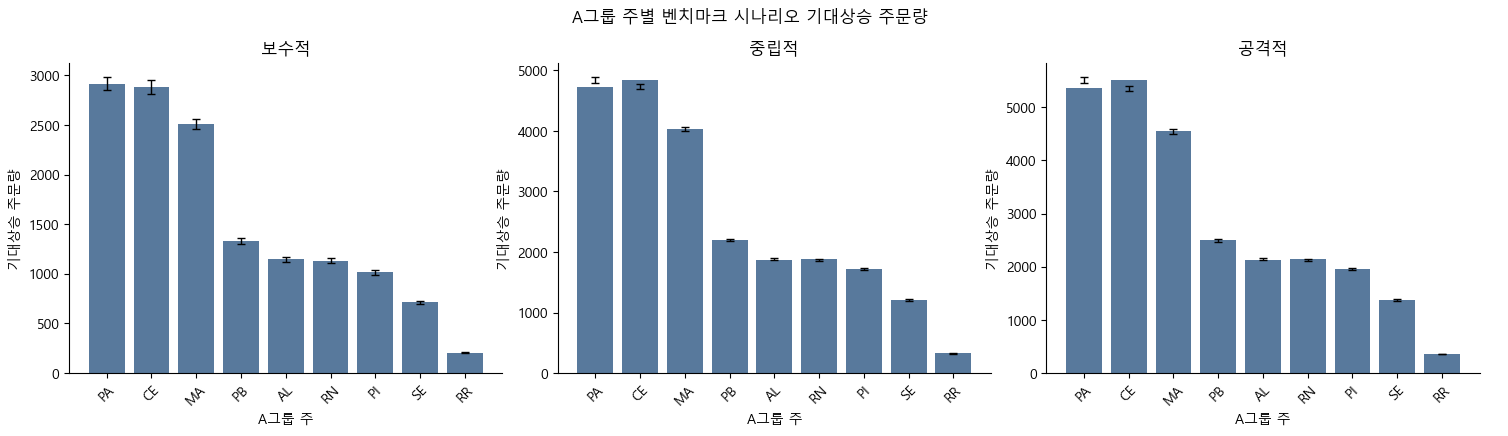

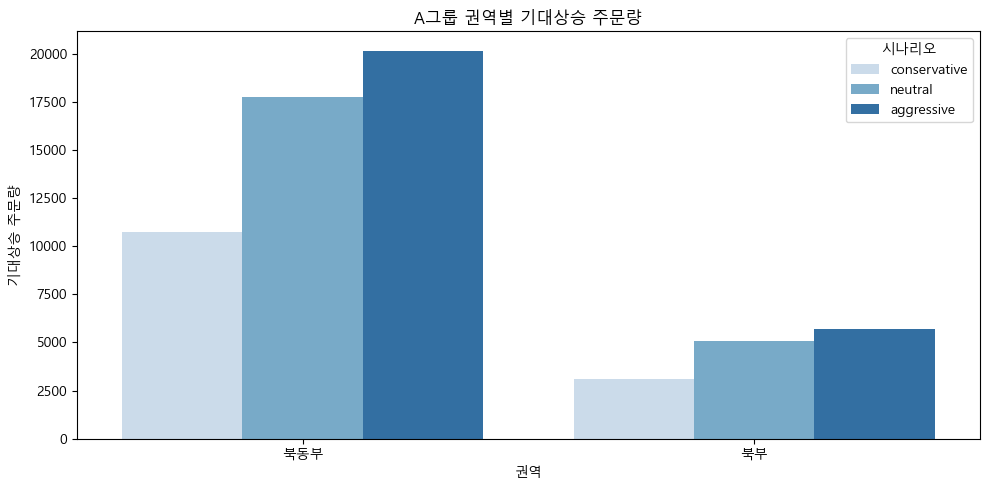

In [19]:
scenario_order = ["conservative", "neutral", "aggressive"]
scenario_name_map = {
    "conservative": "보수적",
    "neutral": "중립적",
    "aggressive": "공격적",
}

plot_state = state_expected_hub.copy()
plot_state["scenario"] = pd.Categorical(plot_state["scenario"], categories=scenario_order, ordered=True)
plot_state = plot_state.sort_values(["scenario", "expected_additional_orders"], ascending=[True, False])

g = sns.catplot(
    data=plot_state,
    kind="bar",
    x="uf",
    y="expected_additional_orders",
    col="scenario",
    col_order=scenario_order,
    sharey=False,
    height=4,
    aspect=1.25,
    color="#4C78A8",
)
for ax, scenario in zip(g.axes.flat, scenario_order):
    sub = plot_state[plot_state["scenario"].eq(scenario)].reset_index(drop=True)
    yerr_lower = sub["expected_additional_orders"] - sub["expected_additional_orders_lower"]
    yerr_upper = sub["expected_additional_orders_upper"] - sub["expected_additional_orders"]
    ax.errorbar(
        x=np.arange(len(sub)),
        y=sub["expected_additional_orders"],
        yerr=[yerr_lower, yerr_upper],
        fmt="none",
        ecolor="black",
        elinewidth=1,
        capsize=3,
    )
    ax.set_title(scenario_name_map[scenario])
    ax.set_xlabel("A그룹 주")
    ax.set_ylabel("기대상승 주문량")
    ax.tick_params(axis="x", rotation=45)
g.fig.suptitle("A그룹 주별 벤치마크 시나리오 기대상승 주문량", y=1.05)
plt.show()

plt.figure(figsize=(10, 5))
sns.barplot(
    data=region_expected_from_states,
    x="region",
    y="expected_additional_orders",
    hue="scenario",
    hue_order=scenario_order,
    palette="Blues",
)
plt.title("A그룹 권역별 기대상승 주문량")
plt.xlabel("권역")
plt.ylabel("기대상승 주문량")
plt.legend(title="시나리오")
plt.tight_layout()
plt.show()

## 10. ML 보완 분석: 벤치마크 기반 잠재 회복률 시뮬레이션

기존 ML 파트는 주별 이용률 잔차를 설명하는 보조 모델이었다. 이 수정본에서는 GDP, 인구밀도, 판매자 규모, 배송 조건을 통제한 뒤 남동부 수준의 물류 조건을 가정했을 때 13개 공동집하거점 후보지가 현재 격차를 얼마나 회복할 수 있는지 추정한다.

> 이 결과는 인프라 설치의 확정 인과효과가 아니라, 벤치마크 기반 머신러닝 시뮬레이션으로 산출한 잠재 회복률이다.


In [20]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import RidgeCV
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

sns.set_theme(style='whitegrid', font='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

ROOT = Path.cwd()
if ROOT.name == 'Logistics_folder':
    ROOT = ROOT.parents[3]

DATA_DIR = ROOT / 'data'
OUTPUT_DIR = ROOT / 'notebooks' / 'Distribution_hub' / 'SG' / 'Logistics_folder' / 'outputs'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

### 10.1 데이터 로드와 경제 통제 변수 병합

In [21]:
state_usage = pd.read_csv(OUTPUT_DIR / 'population_adjusted_state_usage.csv')
infra_candidates = pd.read_csv(OUTPUT_DIR / 'infrastructure_investment_candidates.csv')
hub_candidates = pd.read_csv(OUTPUT_DIR / 'unweighted_dual_side_micro_hub_candidates.csv')
gdp = pd.read_csv(DATA_DIR / 'brazil_state_gdp_population_density_2016_2018_ibge_population.csv')

gdp_avg = (
    gdp.groupby(['uf', 'state', 'region'], as_index=False)
    .agg(
        경제통제_GDP_per_capita=('gdp_per_capita_current_brl_calculated', 'mean'),
        경제통제_총GDP_BRL=('gdp_current_brl', 'mean'),
        경제통제_IBGE인구=('population_ibge_estimate', 'mean'),
        경제통제_인구밀도=('population_density_per_km2', 'mean'),
        경제통제_면적_km2=('area_km2', 'mean'),
    )
)

display(gdp_avg.head())

,uf,state,region,경제통제_GDP_per_capita,경제통제_총GDP_BRL,경제통제_IBGE인구,경제통제_인구밀도,경제통제_면적_km2
0,AC,Acre,북부,"17,227.5333","14,452,767,720.4600","838,523.6667",5.1075,"164,173.4310"
1,AL,Alagoas,북동부,"15,586.2333","52,244,284,835.6700","3,352,535.3333",120.4619,"27,830.6560"
2,AM,Amazonas,북부,"23,242.9033","94,129,735,992.8967","4,048,630.6667",2.5965,"1,559,255.8810"
3,AP,Amapá,북부,"19,329.5300","15,539,750,024.4633","803,170.3333",5.6374,"142,470.7620"
4,BA,Bahia,북동부,"17,924.6067","271,234,200,533.1133","15,144,543.3333",26.8158,"564,760.4290"


### 10.2 판매자 규모 파생컬럼 생성

In [22]:
orders = pd.read_csv(DATA_DIR / 'olist_orders_dataset.csv', usecols=['order_id', 'order_status', 'order_purchase_timestamp'])
order_items = pd.read_csv(DATA_DIR / 'olist_order_items_dataset.csv', usecols=['order_id', 'seller_id'])
sellers = pd.read_csv(DATA_DIR / 'olist_sellers_dataset.csv', usecols=['seller_id', 'seller_state'])

orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'], errors='coerce')
seller_base = (
    order_items.merge(orders, on='order_id', how='left')
    .merge(sellers, on='seller_id', how='left')
    .query("order_status == 'delivered'")
    .groupby('seller_state', as_index=False)
    .agg(
        판매주문수=('order_id', 'nunique'),
        판매자수=('seller_id', 'nunique'),
        판매상품수=('seller_id', 'size'),
    )
    .rename(columns={'seller_state': 'uf'})
)

model_df = (
    state_usage.merge(gdp_avg.drop(columns=['state', 'region']), on='uf', how='left')
    .merge(seller_base, on='uf', how='left')
)
model_df[['판매주문수', '판매자수', '판매상품수']] = model_df[['판매주문수', '판매자수', '판매상품수']].fillna(0)
model_df['판매주문율_10만명당'] = model_df['판매주문수'] / model_df['avg_population'] * 100_000
model_df['판매자밀도_10만명당'] = model_df['판매자수'] / model_df['avg_population'] * 100_000
model_df['후보그룹'] = model_df['uf'].map(infra_candidates.set_index('uf')['candidate_group']).fillna('non_candidate')

display(model_df.head())

,uf,region,orders,customers,items,orders_per_100k,customers_per_100k,items_per_100k,avg_review_score,median_delivery_days,avg_delivery_days,late_rate,avg_delivery_vs_estimated_days,avg_freight,state,avg_population,경제통제_GDP_per_capita,경제통제_총GDP_BRL,경제통제_IBGE인구,경제통제_인구밀도,경제통제_면적_km2,판매주문수,판매자수,판매상품수,판매주문율_10만명당,판매자밀도_10만명당,후보그룹
0,SP,남동부,39902,38584,45758,88.4199,85.4993,101.3964,4.2444,7.0000,8.3391,0.0595,-10.3417,17.3229,São Paulo,"45,127,833.6667","47,043.4200","2,123,360,322,075.8770","45,127,833.6667",181.8062,"248,219.4850","68,641.0000","1,769.0000","78,604.0000",152.1035,3.9200,D_mature_or_lower_priority
1,RJ,남동부,12210,11785,13970,72.5132,69.9892,82.9656,3.9627,12.0000,14.9156,0.1360,-10.9573,23.9347,Rio de Janeiro,"16,838,304.0000","40,962.6267","690,288,640,457.0100","16,838,304.0000",384.8718,"43,750.4250","4,227.0000",163.0000,"4,685.0000",25.1035,0.9680,B_logistics_bottleneck_in_existing_market
2,DF,중서부,2041,1981,2312,68.0987,66.0968,77.1407,4.1300,11.0000,12.5938,0.0720,-11.2777,23.7872,Distrito Federal,"2,997,121.0000","81,763.6833","245,026,499,613.4500","2,997,121.0000",520.2627,"5,760.7840",808.0000,30.0000,883.0000,26.9592,1.0010,D_mature_or_lower_priority
3,MG,남동부,11186,10838,12723,53.1336,51.4806,60.4344,4.1906,10.0000,11.6067,0.0567,-12.4932,23.4831,Minas Gerais,"21,052,586.0000","27,486.9000","578,687,277,623.6434","21,052,586.0000",35.8944,"586,513.9830","7,735.0000",236.0000,"8,603.0000",36.7413,1.1210,D_mature_or_lower_priority
4,SC,남부,3492,3395,4032,49.9161,48.5296,57.6351,4.1293,13.0000,14.5570,0.0991,-10.7265,24.8598,Santa Catarina,"6,995,736.0000","39,635.5900","277,417,331,718.6434","6,995,736.0000",73.0772,"95,730.6900","3,603.0000",184.0000,"4,000.0000",51.5028,2.6302,D_mature_or_lower_priority


### 10.3 남동부 벤치마크 정의

In [23]:
southeast = model_df[model_df['region'].eq('남동부')]
benchmark = {
    'orders_per_100k': np.average(southeast['orders_per_100k'], weights=southeast['avg_population']),
    'customers_per_100k': np.average(southeast['customers_per_100k'], weights=southeast['avg_population']),
    '판매주문율_10만명당': np.average(southeast['판매주문율_10만명당'], weights=southeast['avg_population']),
    'avg_review_score': np.average(southeast['avg_review_score'], weights=southeast['orders']),
    'avg_delivery_days': np.average(southeast['avg_delivery_days'], weights=southeast['orders']),
    'late_rate': np.average(southeast['late_rate'], weights=southeast['orders']),
    'avg_freight': np.average(southeast['avg_freight'], weights=southeast['orders']),
}

pd.Series(benchmark, name='남동부_벤치마크')

orders_per_100k      75.0130
customers_per_100k   72.5351
판매주문율_10만명당          92.9968
avg_review_score      4.1775
avg_delivery_days    10.3420
late_rate             0.0753
avg_freight          19.8320
Name: 남동부_벤치마크, dtype: float64

### 10.4 머신러닝 시뮬레이션

In [24]:
numeric_features = [
    '경제통제_GDP_per_capita',
    '경제통제_인구밀도',
    'avg_population',
    '판매주문율_10만명당',
    '판매자밀도_10만명당',
    'avg_delivery_days',
    'late_rate',
    'avg_freight',
    'avg_review_score',
]
categorical_features = ['region']
target_features = {
    'orders_per_100k': [c for c in numeric_features if c != 'avg_review_score'],
    'customers_per_100k': [c for c in numeric_features if c != 'avg_review_score'],
    '판매주문율_10만명당': [
        '경제통제_GDP_per_capita', '경제통제_인구밀도', 'avg_population',
        'avg_delivery_days', 'late_rate', 'avg_freight', 'avg_review_score'
    ],
    'avg_review_score': [
        '경제통제_GDP_per_capita', '경제통제_인구밀도', 'avg_population',
        '판매주문율_10만명당', '판매자밀도_10만명당',
        'avg_delivery_days', 'late_rate', 'avg_freight'
    ],
}

scenario_df = model_df.copy()
scenario_df['avg_delivery_days'] = benchmark['avg_delivery_days']
scenario_df['late_rate'] = benchmark['late_rate']
scenario_df['avg_freight'] = benchmark['avg_freight']

comparison_rows = []
prediction_frames = []
importance_frames = []

for target, target_numeric_features in target_features.items():
    feature_cols = target_numeric_features + categorical_features
    train_df = model_df[feature_cols + [target]].dropna(subset=[target]).copy()
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]), target_numeric_features),
            ('cat', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('onehot', OneHotEncoder(handle_unknown='ignore'))]), categorical_features),
        ]
    )
    models = {
        'Ridge': RidgeCV(alphas=np.logspace(-3, 3, 13)),
        'RandomForest': RandomForestRegressor(n_estimators=600, min_samples_leaf=2, random_state=42),
    }
    best_name = None
    best_mae = np.inf
    fitted_models = {}
    for model_name, model in models.items():
        pipe = Pipeline([('preprocess', preprocessor), ('model', model)])
        pred = cross_val_predict(pipe, train_df[feature_cols], train_df[target], cv=LeaveOneOut())
        mae = mean_absolute_error(train_df[target], pred)
        comparison_rows.append({
            '예측대상': target,
            '모델': model_name,
            'LOO_MAE': mae,
            'LOO_RMSE': root_mean_squared_error(train_df[target], pred),
            'LOO_R2': r2_score(train_df[target], pred),
        })
        pipe.fit(train_df[feature_cols], train_df[target])
        fitted_models[model_name] = pipe
        if mae < best_mae:
            best_mae = mae
            best_name = model_name

    best_pipe = fitted_models[best_name]
    scenario_pred = best_pipe.predict(scenario_df[feature_cols])
    prediction_frames.append(
        model_df[['uf', 'state', 'region', '후보그룹', target]]
        .assign(예측대상=target, 선택모델=best_name, 시나리오예측값=scenario_pred)
    )

model_comparison = pd.DataFrame(comparison_rows).sort_values(['예측대상', 'LOO_MAE'])
scenario_predictions = pd.concat(prediction_frames, ignore_index=True)

display(model_comparison)
display(scenario_predictions.query("후보그룹 == 'A_infra_investment_candidate'").head())

# 기존 저장 셀과 호환되도록 새 ML 결과를 동일 변수명에도 연결한다.
ml_model_comparison = model_comparison.copy()
ml_state_predictions = scenario_predictions.copy()
ml_feature_importance = pd.DataFrame(columns=['예측대상', '변수', '중요도_MAE감소'])


,예측대상,모델,LOO_MAE,LOO_RMSE,LOO_R2
7,avg_review_score,RandomForest,0.0664,0.0826,0.5733
6,avg_review_score,Ridge,0.0703,0.0892,0.5018
2,customers_per_100k,Ridge,4.4379,6.2295,0.9170
3,customers_per_100k,RandomForest,5.0104,8.0826,0.8603
0,orders_per_100k,Ridge,4.6193,6.5208,0.9150
1,orders_per_100k,RandomForest,5.1642,8.3932,0.8592
5,판매주문율_10만명당,RandomForest,10.9497,24.4807,0.4013
4,판매주문율_10만명당,Ridge,16.4137,24.6752,0.3917


,uf,state,region,후보그룹,orders_per_100k,예측대상,선택모델,시나리오예측값,customers_per_100k,판매주문율_10만명당,avg_review_score
14,SE,Sergipe,북동부,A_infra_investment_candidate,14.6219,orders_per_100k,Ridge,23.2829,NaN,NaN,NaN
15,PI,Piauí,북동부,A_infra_investment_candidate,14.5112,orders_per_100k,Ridge,18.7067,NaN,NaN,NaN
16,CE,Ceará,북동부,A_infra_investment_candidate,13.9580,orders_per_100k,Ridge,24.2447,NaN,NaN,NaN
18,RN,Rio Grande do Norte,북동부,A_infra_investment_candidate,13.3926,orders_per_100k,Ridge,22.7494,NaN,NaN,NaN
19,PB,Paraíba,북동부,A_infra_investment_candidate,12.7023,orders_per_100k,Ridge,21.9970,NaN,NaN,NaN


### 10.5 13개 후보지 Gap Closure Rate 계산

In [25]:
def clipped_gap_closure(current, predicted, benchmark_value):
    denominator = benchmark_value - current
    raw = (predicted - current) / denominator * 100
    raw = raw.where(denominator > 0, np.nan)
    return raw.clip(lower=0, upper=100)

wide_pred = scenario_predictions.pivot_table(
    index=['uf', 'state', 'region', '후보그룹'],
    columns='예측대상',
    values='시나리오예측값',
    aggfunc='first',
).reset_index()

candidate_base = (
    model_df[model_df['후보그룹'].eq('A_infra_investment_candidate')]
    .merge(
        hub_candidates[
            ['state', 'suggested_city', 'avg_distance_to_hub_km', 'p75_distance_to_hub_km', 'rank_mean', 'top5_count']
        ].rename(columns={'state': 'uf'}),
        on='uf',
        how='left',
    )
    .merge(
        wide_pred.drop(columns=['state', 'region', '후보그룹']),
        on='uf',
        how='left',
        suffixes=('', '_예측'),
    )
)

result = pd.DataFrame({
    '주': candidate_base['uf'],
    '주명': candidate_base['state'],
    '권역': candidate_base['region'],
    '후보도시': candidate_base['suggested_city'],
    '현재_주문율_10만명당': candidate_base['orders_per_100k'],
    '예측_주문율_10만명당': np.maximum(candidate_base['orders_per_100k'], candidate_base['orders_per_100k_예측']),
    '벤치마크_주문율_10만명당': benchmark['orders_per_100k'],
    '현재_고객율_10만명당': candidate_base['customers_per_100k'],
    '예측_고객율_10만명당': np.maximum(candidate_base['customers_per_100k'], candidate_base['customers_per_100k_예측']),
    '벤치마크_고객율_10만명당': benchmark['customers_per_100k'],
    '현재_판매주문율_10만명당': candidate_base['판매주문율_10만명당'],
    '예측_판매주문율_10만명당': np.maximum(candidate_base['판매주문율_10만명당'], candidate_base['판매주문율_10만명당_예측']),
    '벤치마크_판매주문율_10만명당': benchmark['판매주문율_10만명당'],
    '현재_리뷰배송점수': candidate_base['avg_review_score'],
    '예측_리뷰배송점수': np.maximum(candidate_base['avg_review_score'], candidate_base['avg_review_score_예측']),
    '벤치마크_리뷰배송점수': benchmark['avg_review_score'],
    '현재_평균배송일': candidate_base['avg_delivery_days'],
    '시나리오_평균배송일': benchmark['avg_delivery_days'],
    '현재_지연율': candidate_base['late_rate'],
    '시나리오_지연율': benchmark['late_rate'],
    '경제통제_1인당GDP': candidate_base['경제통제_GDP_per_capita'],
    '경제통제_인구밀도': candidate_base['경제통제_인구밀도'],
    '거점평균거리_km': candidate_base['avg_distance_to_hub_km'],
    '거점75퍼센트거리_km': candidate_base['p75_distance_to_hub_km'],
})

result['주문율_격차회복률_pct'] = clipped_gap_closure(result['현재_주문율_10만명당'], result['예측_주문율_10만명당'], benchmark['orders_per_100k'])
result['고객율_격차회복률_pct'] = clipped_gap_closure(result['현재_고객율_10만명당'], result['예측_고객율_10만명당'], benchmark['customers_per_100k'])
result['판매주문율_격차회복률_pct'] = clipped_gap_closure(result['현재_판매주문율_10만명당'], result['예측_판매주문율_10만명당'], benchmark['판매주문율_10만명당'])
result['리뷰배송점수_격차회복률_pct'] = clipped_gap_closure(result['현재_리뷰배송점수'], result['예측_리뷰배송점수'], benchmark['avg_review_score'])
result['종합_격차회복률_pct'] = result[
    ['주문율_격차회복률_pct', '고객율_격차회복률_pct', '판매주문율_격차회복률_pct', '리뷰배송점수_격차회복률_pct']
].mean(axis=1)

result = result.sort_values('종합_격차회복률_pct', ascending=False)
display(result)

,주,주명,권역,후보도시,현재_주문율_10만명당,예측_주문율_10만명당,벤치마크_주문율_10만명당,현재_고객율_10만명당,예측_고객율_10만명당,벤치마크_고객율_10만명당,현재_판매주문율_10만명당,예측_판매주문율_10만명당,벤치마크_판매주문율_10만명당,현재_리뷰배송점수,예측_리뷰배송점수,벤치마크_리뷰배송점수,현재_평균배송일,시나리오_평균배송일,현재_지연율,시나리오_지연율,경제통제_1인당GDP,경제통제_인구밀도,거점평균거리_km,거점75퍼센트거리_km,주문율_격차회복률_pct,고객율_격차회복률_pct,판매주문율_격차회복률_pct,리뷰배송점수_격차회복률_pct,종합_격차회복률_pct
12,RR,Roraima,북부,boa vista,7.4376,23.9038,75.0130,7.2516,23.2445,72.5351,0.0000,68.5409,92.9968,3.8750,4.1511,4.1775,29.4500,10.3420,0.1250,0.0753,"22,588.9300",2.4048,12.8633,8.2916,24.3672,24.4976,73.7024,91.2589,53.4565
8,PA,Pará,북부,quatro bocas,11.1637,25.7411,75.0130,10.8775,24.9520,72.5351,0.0954,68.5852,92.9968,3.9090,4.1165,4.1775,23.3494,10.3420,0.1229,0.0753,"18,066.7633",6.7297,269.9434,310.6866,22.8309,22.8268,73.7230,77.2767,49.1644
9,PA,Pará,북부,porto trombetas,11.1637,25.7411,75.0130,10.8775,24.9520,72.5351,0.0954,68.5852,92.9968,3.9090,4.1165,4.1775,23.3494,10.3420,0.1229,0.0753,"18,066.7633",6.7297,0.0000,0.0000,22.8309,22.8268,73.7230,77.2767,49.1644
7,AL,Alagoas,북동부,anadia,11.7225,23.2618,75.0130,11.4242,22.6643,72.5351,0.0000,68.5675,92.9968,3.8718,4.1096,4.1775,23.8779,10.3420,0.2366,0.0753,"15,586.2333",120.4619,75.1028,67.1964,18.2323,18.3930,73.7310,77.7790,47.0338
10,MA,Maranhão,북동부,santa rita,10.0623,20.1565,75.0130,9.8193,19.6518,72.5351,5.5600,68.6345,92.9968,3.8362,4.1128,4.1775,21.2188,10.3420,0.2003,0.0753,"13,004.9500",21.2237,117.9973,160.3470,15.5414,15.6779,72.1372,81.0463,46.1007
11,MA,Maranhão,북동부,grajau,10.0623,20.1565,75.0130,9.8193,19.6518,72.5351,5.5600,68.6345,92.9968,3.8362,4.1128,4.1775,21.2188,10.3420,0.2003,0.0753,"13,004.9500",21.2237,177.7360,213.6199,15.5414,15.6779,72.1372,81.0463,46.1007
2,CE,Ceará,북동부,caucaia,13.9580,24.2447,75.0130,13.7252,23.5960,72.5351,0.9645,68.6149,92.9968,3.9401,4.1149,4.1775,20.9460,10.3420,0.1557,0.0753,"16,339.7800",60.5793,74.5773,121.1434,16.8483,16.7843,73.5072,73.6098,45.1874
3,CE,Ceará,북동부,varzea alegre,13.9580,24.2447,75.0130,13.7252,23.5960,72.5351,0.9645,68.6149,92.9968,3.9401,4.1149,4.1775,20.9460,10.3420,0.1557,0.0753,"16,339.7800",60.5793,79.5278,102.9115,16.8483,16.7843,73.5072,73.6098,45.1874
0,SE,Sergipe,북동부,riachuelo,14.6219,23.2829,75.0130,14.4024,22.7072,72.5351,0.3952,68.5657,92.9968,3.9066,4.1121,4.1775,21.0961,10.3420,0.1532,0.0753,"17,797.9133",103.8099,42.4721,57.4964,14.3415,14.2859,73.6169,75.8540,44.5246
1,PI,Piauí,북동부,lagoinha do piaui,14.5112,18.7067,75.0130,14.1399,18.2808,72.5351,0.3403,68.5631,92.9968,4.0022,4.1194,4.1775,19.1215,10.3420,0.1620,0.0753,"14,139.2333",12.8378,169.3592,248.9222,6.9346,7.0912,73.6298,66.8603,38.6290


### 10.6 시각화와 저장

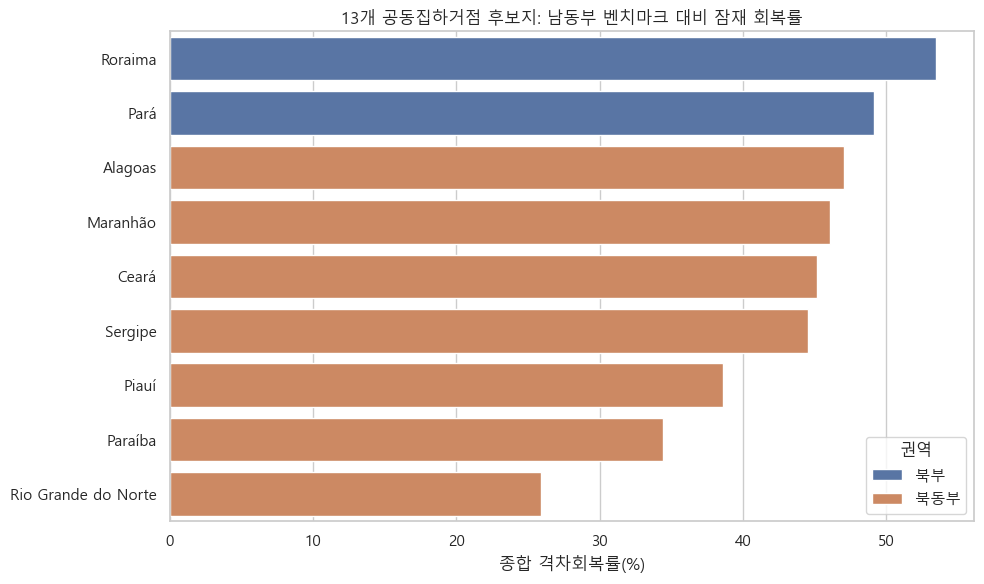

,주,주명,권역,후보도시,주문율_격차회복률_pct,고객율_격차회복률_pct,판매주문율_격차회복률_pct,리뷰배송점수_격차회복률_pct,종합_격차회복률_pct
12,RR,Roraima,북부,boa vista,24.3672,24.4976,73.7024,91.2589,53.4565
8,PA,Pará,북부,quatro bocas,22.8309,22.8268,73.7230,77.2767,49.1644
9,PA,Pará,북부,porto trombetas,22.8309,22.8268,73.7230,77.2767,49.1644
7,AL,Alagoas,북동부,anadia,18.2323,18.3930,73.7310,77.7790,47.0338
10,MA,Maranhão,북동부,santa rita,15.5414,15.6779,72.1372,81.0463,46.1007
11,MA,Maranhão,북동부,grajau,15.5414,15.6779,72.1372,81.0463,46.1007
2,CE,Ceará,북동부,caucaia,16.8483,16.7843,73.5072,73.6098,45.1874
3,CE,Ceará,북동부,varzea alegre,16.8483,16.7843,73.5072,73.6098,45.1874
0,SE,Sergipe,북동부,riachuelo,14.3415,14.2859,73.6169,75.8540,44.5246
1,PI,Piauí,북동부,lagoinha do piaui,6.9346,7.0912,73.6298,66.8603,38.6290


In [26]:
save_cols = [
    '주', '주명', '권역', '후보도시',
    '주문율_격차회복률_pct', '고객율_격차회복률_pct',
    '판매주문율_격차회복률_pct', '리뷰배송점수_격차회복률_pct',
    '종합_격차회복률_pct',
]

plt.figure(figsize=(10, 6))
sns.barplot(data=result, y='주명', x='종합_격차회복률_pct', hue='권역', dodge=False)
plt.title('13개 공동집하거점 후보지: 남동부 벤치마크 대비 잠재 회복률')
plt.xlabel('종합 격차회복률(%)')
plt.ylabel('')
plt.legend(title='권역', loc='lower right')
plt.tight_layout()
plt.show()

result.to_csv(OUTPUT_DIR / 'unweighted_revised_benchmark_gap_closure.csv', index=False, encoding='utf-8-sig')
model_comparison.to_csv(OUTPUT_DIR / 'unweighted_revised_ml_model_comparison.csv', index=False, encoding='utf-8-sig')
ml_model_comparison.to_csv(OUTPUT_DIR / 'unweighted_usage_ml_model_comparison.csv', index=False, encoding='utf-8-sig')
ml_state_predictions.to_csv(OUTPUT_DIR / 'unweighted_usage_ml_state_predictions.csv', index=False, encoding='utf-8-sig')
ml_feature_importance.to_csv(OUTPUT_DIR / 'unweighted_usage_ml_feature_importance.csv', index=False, encoding='utf-8-sig')

display(result[save_cols])

### 10.7 최종 요약표: 종합회복률과 시나리오별 이용률

아래 표는 13개 공동집하거점 후보를 한 번에 비교하기 위한 최종 요약표다.

- `종합_격차회복률_pct`: 남동부 수준의 물류 조건을 가정했을 때 현재 격차 중 회복 가능한 비율
- `보수/중립/공격_목표주문율_10만명당`: 각 벤치마크 시나리오에서 가정한 인구 10만 명당 주문율
- `보수/중립/공격_기대상승주문건수`: 각 시나리오의 목표 주문율까지 따라잡는다고 가정했을 때의 추가 주문 건수

따라서 이 표는 `입지 후보`, `ML 기반 회복 가능성`, `시나리오별 시장 규모`를 함께 보는 최종 의사결정 표다.

In [ ]:
scenario_name_map = {
    'conservative': '보수',
    'neutral': '중립',
    'aggressive': '공격',
}

if 'state_expected_hub' not in globals():
    state_expected_hub = pd.read_csv(OUTPUT_DIR / 'unweighted_hub_expected_order_uplift.csv')

scenario_usage = state_expected_hub[
    ['uf', 'scenario', 'benchmark_orders_per_100k', 'expected_additional_orders']
].copy()
scenario_usage['시나리오'] = scenario_usage['scenario'].map(scenario_name_map)

scenario_usage_wide = (
    scenario_usage
    .pivot_table(
        index='uf',
        columns='시나리오',
        values=['benchmark_orders_per_100k', 'expected_additional_orders'],
        aggfunc='first',
    )
)
scenario_usage_wide.columns = [
    f'{scenario}_목표주문율_10만명당' if metric == 'benchmark_orders_per_100k'
    else f'{scenario}_기대상승주문건수'
    for metric, scenario in scenario_usage_wide.columns
]
scenario_usage_wide = scenario_usage_wide.reset_index()

final_recovery_scenario_table = (
    result
    .merge(scenario_usage_wide, left_on='주', right_on='uf', how='left')
    .drop(columns=['uf'])
)

final_recovery_scenario_table = final_recovery_scenario_table[
    [
        '주', '주명', '권역', '후보도시',
        '현재_주문율_10만명당',
        '예측_주문율_10만명당',
        '종합_격차회복률_pct',
        '보수_목표주문율_10만명당',
        '중립_목표주문율_10만명당',
        '공격_목표주문율_10만명당',
        '보수_기대상승주문건수',
        '중립_기대상승주문건수',
        '공격_기대상승주문건수',
    ]
].sort_values('종합_격차회복률_pct', ascending=False)

round_cols = [
    '현재_주문율_10만명당',
    '예측_주문율_10만명당',
    '종합_격차회복률_pct',
    '보수_목표주문율_10만명당',
    '중립_목표주문율_10만명당',
    '공격_목표주문율_10만명당',
    '보수_기대상승주문건수',
    '중립_기대상승주문건수',
    '공격_기대상승주문건수',
]
final_recovery_scenario_table[round_cols] = final_recovery_scenario_table[round_cols].round(2)

display(final_recovery_scenario_table)

final_recovery_scenario_table.to_csv(
    OUTPUT_DIR / 'unweighted_final_recovery_scenario_table.csv',
    index=False,
    encoding='utf-8-sig',
)

### 발표 문장

본 분석은 GDP, 인구밀도, 판매자 규모, 기존 배송 조건을 통제한 뒤, 남동부 수준의 물류 조건을 가정했을 때 13개 공동집하거점 후보지가 현재 격차를 얼마나 회복할 수 있는지 추정한 것이다.

따라서 결과값은 인프라 설치의 확정 인과효과가 아니라, 벤치마크 기반 머신러닝 시뮬레이션으로 산출한 잠재 회복률이다.

## 11. 후보 거점 시각화

아래 그래프는 A그룹 주의 고객/판매자 포인트와 추천 거점 후보를 좌표상에 표시한다. 점수는 후보 거점의 크기로 표현한다.

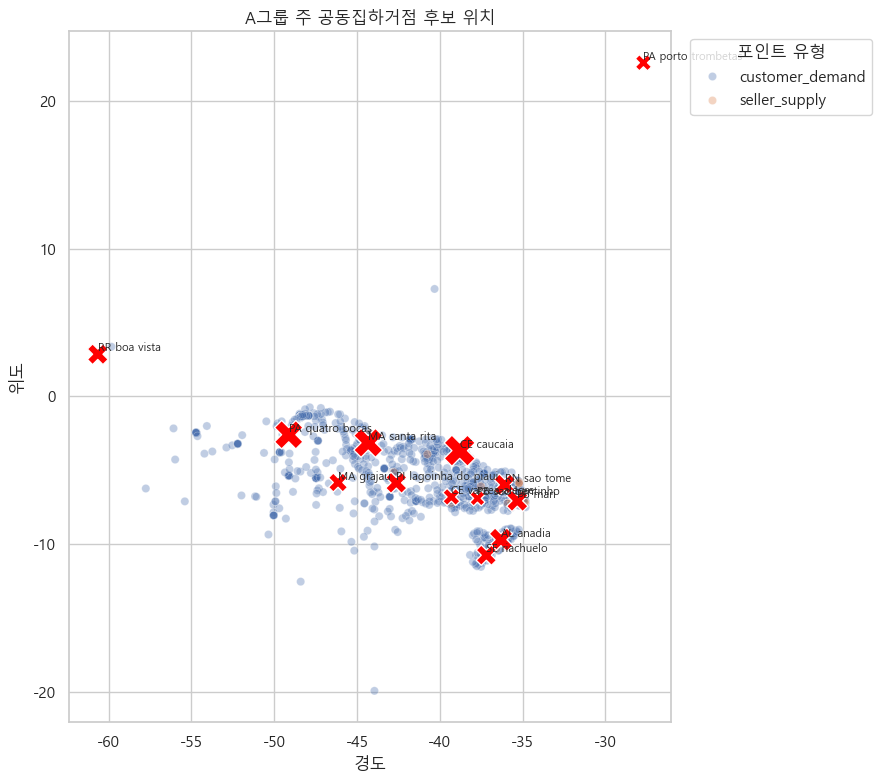

In [27]:
plt.figure(figsize=(9, 8))

sns.scatterplot(
    data=hub_candidate_points,
    x="lng",
    y="lat",
    hue="point_role",
    s=35,
    alpha=0.35
)

sns.scatterplot(
    data=hub_candidates,
    x="hub_lng",
    y="hub_lat",
    size="hub_score",
    sizes=(120, 500),
    color="red",
    marker="X",
    legend=False
)

for _, row in hub_candidates.iterrows():
    plt.text(
        row["hub_lng"],
        row["hub_lat"],
        f"{row['state']} {row['suggested_city']}",
        fontsize=8,
        ha="left",
        va="bottom"
    )

plt.title("A그룹 주 공동집하거점 후보 위치")
plt.xlabel("경도")
plt.ylabel("위도")
plt.legend(title="포인트 유형", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

### 인터랙티브 지도 HTML 생성

`folium`이 설치되어 있지 않아, Leaflet 기반 HTML을 직접 생성합니다. 저장된 HTML 파일을 브라우저에서 열면 OpenStreetMap 배경 위에 고객 수요 포인트, 판매자 공급 포인트, 후보 거점을 레이어별로 확인할 수 있습니다.

주의: HTML 지도는 Leaflet 라이브러리와 OpenStreetMap 타일을 CDN에서 불러오기 때문에, 브라우저에서 인터넷 연결이 가능해야 배경 지도가 표시됩니다.

In [28]:
import json

# 무가중 K-Means 이후 지도용 포인트 분리
customer_points_map = hub_candidate_points[
    hub_candidate_points["point_role"].eq("customer_demand")
].copy()

seller_points_map = hub_candidate_points[
    hub_candidate_points["point_role"].eq("seller_supply")
].copy()

print("고객 수요 포인트:", len(customer_points_map))
print("판매자 공급 포인트:", len(seller_points_map))
print("후보 거점:", len(hub_candidates))

MAP_PATH = OUTPUT_DIR / "unweighted_dual_side_micro_hub_map.html"

# 지도 표시용 샘플링
customer_map_points = (
    customer_points_map
    .sort_values("customer_orders", ascending=False)
    .head(600)
    .copy()
)

seller_map_points = (
    seller_points_map
    .sort_values("seller_orders", ascending=False)
    .head(250)
    .copy()
    if not seller_points_map.empty
    else pd.DataFrame()
)

def make_records(df, cols):
    temp = df.copy()
    for col in cols:
        if col not in temp.columns:
            temp[col] = None
    temp = temp[cols].where(pd.notna(temp[cols]), None)
    return temp.to_dict(orient="records")

customer_cols = [
    "state",
    "region",
    "city",
    "zip_code_prefix",
    "lat",
    "lng",
    "customer_orders",
    "customers",
    "avg_delivery_days",
    "late_rate",
]

seller_cols = [
    "state",
    "region",
    "city",
    "zip_code_prefix",
    "lat",
    "lng",
    "seller_orders",
    "sellers",
]

hub_cols = [
    "state",
    "region",
    "suggested_city",
    "suggested_zip_code_prefix",
    "hub_lat",
    "hub_lng",
    "hub_score",
    "covered_customer_orders",
    "covered_customers",
    "covered_seller_orders",
    "covered_sellers",
    "avg_delivery_days",
    "late_rate",
    "avg_distance_to_hub_km",
]

customer_map_data = make_records(customer_map_points, customer_cols)
seller_map_data = make_records(seller_map_points, seller_cols)
hub_map_data = make_records(hub_candidates, hub_cols)

center_lat = float(hub_candidates["hub_lat"].mean())
center_lng = float(hub_candidates["hub_lng"].mean())

html = f"""
<!DOCTYPE html>
<html lang="ko">
<head>
  <meta charset="utf-8" />
  <title>A그룹 공동집하거점 후보 지도</title>
  <meta name="viewport" content="width=device-width, initial-scale=1.0">

  <link rel="stylesheet" href="https://unpkg.com/leaflet@1.9.4/dist/leaflet.css" />
  <script src="https://unpkg.com/leaflet@1.9.4/dist/leaflet.js"></script>

  <style>
    body {{
      margin: 0;
      font-family: Arial, sans-serif;
    }}

    #map {{
      height: 100vh;
      width: 100vw;
    }}

    .legend {{
      background: white;
      padding: 10px 12px;
      border-radius: 6px;
      box-shadow: 0 1px 6px rgba(0, 0, 0, 0.25);
      line-height: 1.5;
      font-size: 13px;
    }}

    .legend span {{
      display: inline-block;
      width: 11px;
      height: 11px;
      border-radius: 50%;
      margin-right: 6px;
    }}
  </style>
</head>

<body>
<div id="map"></div>

<script>
const customerPoints = {json.dumps(customer_map_data, ensure_ascii=False)};
const sellerPoints = {json.dumps(seller_map_data, ensure_ascii=False)};
const hubPoints = {json.dumps(hub_map_data, ensure_ascii=False)};

const map = L.map('map').setView([{center_lat:.6f}, {center_lng:.6f}], 5);

L.tileLayer('https://{{s}}.tile.openstreetmap.org/{{z}}/{{x}}/{{y}}.png', {{
  maxZoom: 18,
  attribution: '&copy; OpenStreetMap contributors'
}}).addTo(map);

const customerLayer = L.layerGroup();
const sellerLayer = L.layerGroup();
const hubLayer = L.layerGroup();

function fmt(value, digits = 2) {{
  if (value === null || value === undefined || Number.isNaN(Number(value))) {{
    return '-';
  }}
  return Number(value).toLocaleString('ko-KR', {{
    maximumFractionDigits: digits
  }});
}}

customerPoints.forEach(p => {{
  const radius = Math.max(3, Math.min(18, Math.sqrt(Number(p.customer_orders || 0)) * 0.9));

  const popup = `
    <b>고객 수요 포인트</b><br>
    주: ${{p.state}} / 권역: ${{p.region}}<br>
    도시: ${{p.city}}<br>
    ZIP: ${{p.zip_code_prefix}}<br>
    주문 수: ${{fmt(p.customer_orders, 0)}}<br>
    고객 수: ${{fmt(p.customers, 0)}}<br>
    평균 배송일: ${{fmt(p.avg_delivery_days)}}일<br>
    지연율: ${{fmt(Number(p.late_rate || 0) * 100)}}%
  `;

  L.circleMarker([p.lat, p.lng], {{
    radius: radius,
    color: '#2166ac',
    fillColor: '#2166ac',
    fillOpacity: 0.35,
    weight: 1
  }}).bindPopup(popup).addTo(customerLayer);
}});

sellerPoints.forEach(p => {{
  const baseSize = Number(p.seller_orders || 0) + 10 * Number(p.sellers || 0);
  const radius = Math.max(4, Math.min(16, Math.sqrt(baseSize) * 0.6));

  const popup = `
    <b>판매자 공급 포인트</b><br>
    주: ${{p.state}} / 권역: ${{p.region}}<br>
    도시: ${{p.city}}<br>
    ZIP: ${{p.zip_code_prefix}}<br>
    판매자 주문 수: ${{fmt(p.seller_orders, 0)}}<br>
    판매자 수: ${{fmt(p.sellers, 0)}}
  `;

  L.circleMarker([p.lat, p.lng], {{
    radius: radius,
    color: '#1b7837',
    fillColor: '#1b7837',
    fillOpacity: 0.45,
    weight: 1
  }}).bindPopup(popup).addTo(sellerLayer);
}});

hubPoints.forEach(p => {{
  const radius = Math.max(9, Math.min(24, Number(p.hub_score || 0) * 28));

  const popup = `
    <b>공동집하거점 후보</b><br>
    주: ${{p.state}} / 권역: ${{p.region}}<br>
    후보 도시: ${{p.suggested_city}}<br>
    ZIP: ${{p.suggested_zip_code_prefix}}<br>
    Hub Score: ${{fmt(p.hub_score, 3)}}<br>
    커버 고객 주문: ${{fmt(p.covered_customer_orders, 0)}}<br>
    커버 고객 수: ${{fmt(p.covered_customers, 0)}}<br>
    커버 판매자 주문: ${{fmt(p.covered_seller_orders, 0)}}<br>
    커버 판매자 수: ${{fmt(p.covered_sellers, 0)}}<br>
    평균 배송일: ${{fmt(p.avg_delivery_days)}}일<br>
    지연율: ${{fmt(Number(p.late_rate || 0) * 100)}}%<br>
    평균 커버 거리: ${{fmt(p.avg_distance_to_hub_km)}}km
  `;

  L.circleMarker([p.hub_lat, p.hub_lng], {{
    radius: radius,
    color: '#b2182b',
    fillColor: '#ef3b2c',
    fillOpacity: 0.9,
    weight: 3
  }}).bindPopup(popup).addTo(hubLayer);
}});

customerLayer.addTo(map);
sellerLayer.addTo(map);
hubLayer.addTo(map);

L.control.layers(null, {{
  '고객 수요 포인트': customerLayer,
  '판매자 공급 포인트': sellerLayer,
  '공동집하거점 후보': hubLayer
}}).addTo(map);

const legend = L.control({{ position: 'bottomright' }});

legend.onAdd = function () {{
  const div = L.DomUtil.create('div', 'legend');
  div.innerHTML = `
    <b>지도 범례</b><br>
    <span style="background:#2166ac"></span>고객 수요 포인트<br>
    <span style="background:#1b7837"></span>판매자 공급 포인트<br>
    <span style="background:#ef3b2c"></span>공동집하거점 후보
  `;
  return div;
}};

legend.addTo(map);
</script>
</body>
</html>
"""

MAP_PATH.write_text(html, encoding="utf-8")

print(f"인터랙티브 지도 HTML 저장 완료: {MAP_PATH}")

고객 수요 포인트: 1487
판매자 공급 포인트: 26
후보 거점: 13
인터랙티브 지도 HTML 저장 완료: c:\team-oldest-olist-analysis\notebooks\Distribution_hub\SG\Logistics_folder\outputs\unweighted_dual_side_micro_hub_map.html


## 12. 결과 저장

In [29]:
customer_points_map.to_csv(
    OUTPUT_DIR / "unweighted_dual_side_hub_customer_points.csv",
    index=False,
    encoding="utf-8-sig"
)

seller_points_map.to_csv(
    OUTPUT_DIR / "unweighted_dual_side_hub_seller_points.csv",
    index=False,
    encoding="utf-8-sig"
)

hub_candidate_points.to_csv(
    OUTPUT_DIR / "unweighted_dual_side_hub_clustered_points.csv",
    index=False,
    encoding="utf-8-sig"
)

hub_candidates.to_csv(
    OUTPUT_DIR / "unweighted_dual_side_micro_hub_candidates.csv",
    index=False,
    encoding="utf-8-sig"
)

state_expected_effect.to_csv(
    OUTPUT_DIR / "unweighted_state_expected_order_uplift.csv",
    index=False,
    encoding="utf-8-sig"
)

region_expected_from_states.to_csv(
    OUTPUT_DIR / "unweighted_region_expected_order_uplift.csv",
    index=False,
    encoding="utf-8-sig"
)

state_expected_hub.to_csv(
    OUTPUT_DIR / "unweighted_hub_expected_order_uplift.csv",
    index=False,
    encoding="utf-8-sig"
)

ml_model_comparison.to_csv(
    OUTPUT_DIR / "unweighted_usage_ml_model_comparison.csv",
    index=False,
    encoding="utf-8-sig"
)

ml_state_predictions.to_csv(
    OUTPUT_DIR / "unweighted_usage_ml_state_predictions.csv",
    index=False,
    encoding="utf-8-sig"
)

ml_feature_importance.to_csv(
    OUTPUT_DIR / "unweighted_usage_ml_feature_importance.csv",
    index=False,
    encoding="utf-8-sig"
)

print(f"saved outputs to: {OUTPUT_DIR}")

saved outputs to: c:\team-oldest-olist-analysis\notebooks\Distribution_hub\SG\Logistics_folder\outputs
